# Dubins3D — CBF / Hand-CBF / Duality CBF

Experiments with CBF safety filters on the Dubins 3D car (state: x, y, θ; control: yaw rate ω).
Obstacle at the origin; nominal policy steers toward a goal at (2, 0).

In [4]:
import functools as ft
import sys
from pathlib import Path
sys.path.insert(0, '../../src')
sys.path.insert(0, '../../src/guardian/src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import flax.linen as nn
import optax

from mrncbf.dyn.dubins3d_avoid import Dubins3DAvoid
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp, rcbf_qp_linear, compute_rcbf_gammas
from mrncbf.utils.jax_utils import jax2np

jax.config.update("jax_enable_x64", False)

task = Dubins3DAvoid()

# ── Simulation constants ──────────────────────────────────────────────────────
DT = 0.05   # finer than class DT=0.1 (Euler steps; 10% of obstacle radius per step)
T  = 50    # steps → 10 s

# ── QP / CBF constants ────────────────────────────────────────────────────────
ALPHA_QP = 1.0          # CBF decay rate α
V_SHIFT  = 0.0          # optional barrier shift
u_lb     = jnp.array([-1.0])
u_ub     = jnp.array([ 1.0])
BASE_KEY = jax.random.PRNGKey(42)

# ── HOCBF alpha — shared by rollouts and the MC filter cell ──────────────────
hocbf_alpha = 1.0   # change here; re-run this cell + later cells to propagate

## Things to change back - default goal for nominal, alpha value, initial conditions, directories for nn and results ##
## Rerun mc's for fixed guardian implementation?

# ── Noise for duality CBF demo ────────────────────────────────────────────────
# STATE_EPS_DUAL = jnp.array([0.1, 0.7, 0.005])   # x, y, theta (m, m, rad)
# STATE_EPS_DUAL = jnp.array([0.0, 0.0, 0.0])
STATE_EPS_DUAL = jnp.array([0.15, 0.15, 0.001])
# STATE_EPS_DUAL = jnp.array([0.1, 0.3, 0.001])
# STATE_EPS_DUAL = jnp.array([0.1, 0.4, 0.001])

# ── Training range for phi network (eps sampled from Uniform[0, EPS_MAX]) ─────
EPS_MAX = jnp.array([0.3, 0.5, 0.02])   # per-dimension max uncertainty radii

# ── NMR-CBF weights path (set to None to retrain from scratch) ───────────────
# NMR_WEIGHTS_DIR = '../../runs/nmr_cbf_dubins3d/32x32/'
# _mc_results_dir = Path('../../runs/nmr_cbf_dubins3d/mc_sweep/16_planes/theta_0.001')
NMR_WEIGHTS_DIR = '../../runs/nmr_cbf_dubins3d/32x32/noclip/'
_mc_results_dir = Path('../../runs/nmr_cbf_dubins3d/mc_sweep/16_planes/theta_0.001/noclip/')

print(f"Task: nx={task.NX}, nu={task.NU}, umax={task.umax:.3f} rad/s")
print(f"Obstacle: center={tuple(float(v) for v in task.pos_obs)}, r={task.radius_obs}")
print(f"DT={DT}s, T={T} steps ({T*DT:.1f}s total)")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = True


Task: nx=3, nu=1, umax=0.785 rad/s
Obstacle: center=(0.0, 0.0), r=0.5
DT=0.05s, T=50 steps (2.5s total)


In [5]:
# ── HJ Reachability: compute backward reachable tube (BRT) ───────────────────
# Runs early so hj_grid / hj_target_values are available for plots.
import hj_reachability as hj

class Dubins3DHJ(hj.ControlAndDisturbanceAffineDynamics):
    """Wraps Dubins3DAvoid into the hj_reachability dynamics interface."""
    def __init__(self, vel=1.0, umax=np.pi/4, dt=0.05,
                 max_disturbance=5e-2,
                 control_mode='max', disturbance_mode='min'):
        self.vel  = vel
        self.umax = umax
        self.dt   = dt
        control_space = hj.sets.Box(jnp.array([-1.0]), jnp.array([1.0]))
        disturbance_space = hj.sets.Box(
            jnp.array([-max_disturbance] * 3),
            jnp.array([ max_disturbance] * 3)
        )
        super().__init__(control_mode, disturbance_mode,
                         control_space, disturbance_space)

    def open_loop_dynamics(self, state, time):
        return jnp.array([
            self.vel * jnp.cos(state[2]),
            self.vel * jnp.sin(state[2]),
            0.0
        ])

    def control_jacobian(self, state, time):
        # u is normalised [-1, 1]; actual omega = umax * u
        return jnp.array([[0.0], [0.0], [self.umax]])

    def disturbance_jacobian(self, state, time):
        return jnp.eye(3)

    def step(self, state, control, disturbance, time=0.):
        return state + self(state, control, disturbance, time) * self.dt


N_GRID = 100   # 45^3 ~91 K grid points
hj_dynamics = Dubins3DHJ(vel=task.VEL, umax=task.umax, dt=DT)

hj_grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(
        np.array([-2.5, -2.5, -np.pi]),
        np.array([ 2.5,  2.5,  np.pi])
    ),
    (N_GRID, N_GRID, N_GRID),
    periodic_dims=2
)

# Target set: obstacle interior (V <= 0 = unsafe)
obs_x, obs_y = float(task.pos_obs[0]), float(task.pos_obs[1])
r_obs = task.radius_obs
hj_initial_values = (
    - r_obs**2
    + (hj_grid.states[..., 0] - obs_x)**2
    + (hj_grid.states[..., 1] - obs_y)**2
)

solver_settings = hj.SolverSettings.with_accuracy(
    'very_high',
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube
)

print('Solving HJ PDE (may take a minute)...')
import time as _time
_t0 = _time.time()
hj_target_values = hj.step(
    solver_settings, hj_dynamics, hj_grid,
    0.0, hj_initial_values, -5.0   # 5 s backward reachable tube
)
print(f'HJ solve done in {_time.time() - _t0:.1f}s')


Solving HJ PDE (may take a minute)...


100%|##########|  5.0000/5.0 [01:23<00:00, 16.73s/sim_s]

HJ solve done in 84.9s


θ slice: idx=50, θ=0.0000 rad
value range: [-0.250, 12.250]


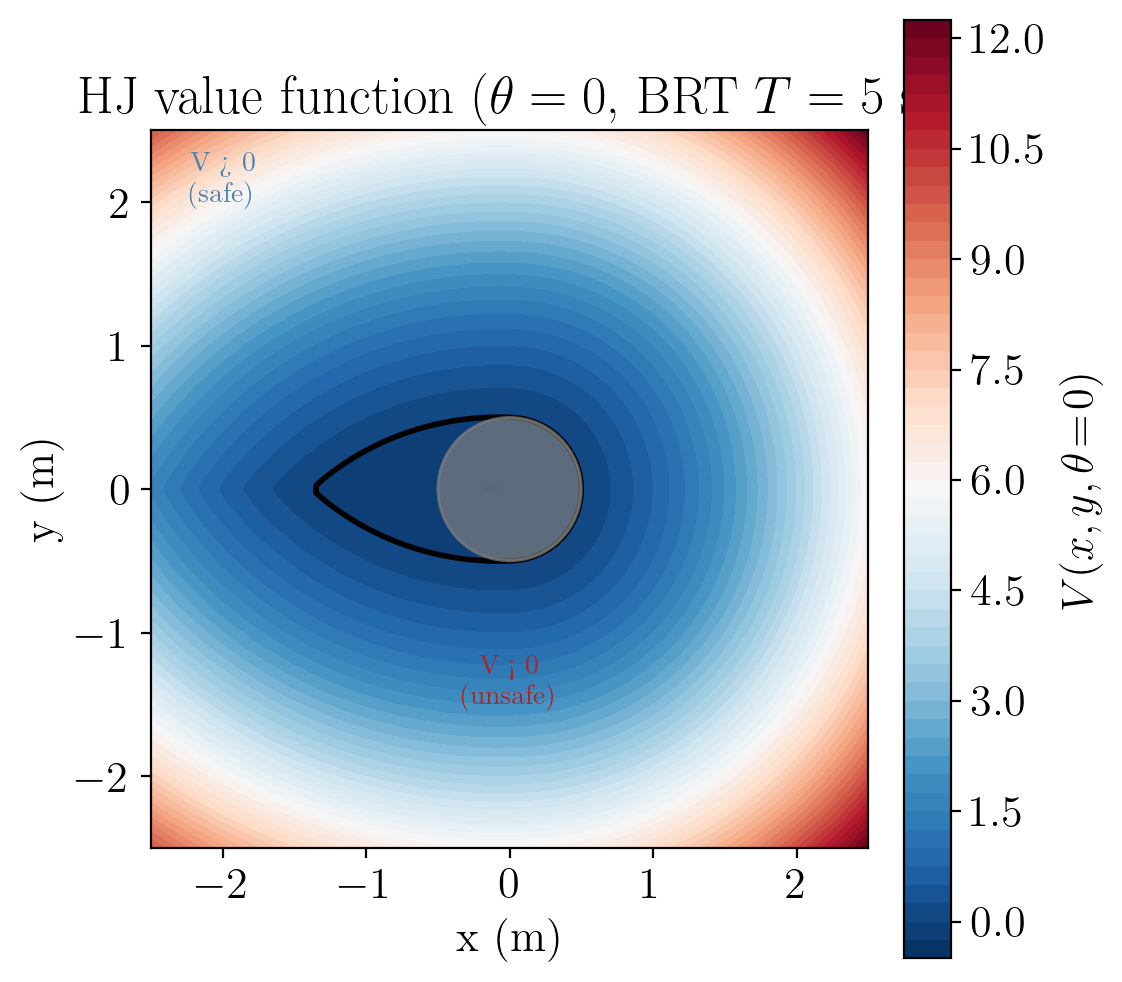

In [6]:
# ── HJ target values: θ=0 slice ──────────────────────────────────────────────
hj_xs     = np.array(hj_grid.coordinate_vectors[0])
hj_ys     = np.array(hj_grid.coordinate_vectors[1])
theta_vec = np.array(hj_grid.coordinate_vectors[2])
theta_idx = int(np.argmin(np.abs(theta_vec)))
hj_slice  = np.array(hj_target_values[:, :, theta_idx])   # (Nx, Ny), indexed [ix, iy]
print(f"θ slice: idx={theta_idx}, θ={theta_vec[theta_idx]:.4f} rad")
print(f"value range: [{hj_slice.min():.3f}, {hj_slice.max():.3f}]")

fig, ax = plt.subplots(figsize=(5.5, 5), layout='constrained')
# contourf/contour(x1d, y1d, Z) expects Z[j,i] (row=y, col=x) → transpose
cm = ax.contourf(hj_xs, hj_ys, hj_slice.T, levels=50, cmap='RdBu_r')
ax.contour(hj_xs, hj_ys, hj_slice.T, levels=[0.0], colors='k', linewidths=2)
fig.colorbar(cm, ax=ax, label=r'$V(x,y,\theta\!=\!0)$')
obs = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                 task.radius_obs, color='gray', alpha=0.7, zorder=3)
ax.add_patch(obs)
ax.set(xlabel='x (m)', ylabel='y (m)', aspect='equal',
       xlim=(hj_xs[0], hj_xs[-1]), ylim=(hj_ys[0], hj_ys[-1]),
       title=rf'HJ value function ($\theta=0$, BRT $T=5$ s)')
ax.annotate('V > 0\n(safe)', xy=(-2.0, 2.0), color='steelblue', fontsize=10, ha='center')
ax.annotate('V < 0\n(unsafe)', xy=(0.0, -1.5), color='firebrick', fontsize=10, ha='center')
plt.show()


## Task verification

Check that the dynamics and safety constraint look correct.

Equilibrium state  x0 = [0. 0. 0.]
Drift  f(x0)          = [1. 0. 0.]  (vel=1.0 m/s eastward at θ=0)
Input  G(x0)          = [0.         0.         0.78539816]
h_components(x0)      = [0.5]  (obstacle dist-r = -0.500 m)
handcbf_B(x0, α=1.0) = [nan]
HJ slice at theta_idx=50 (theta=0.0000 rad)
  value range: [-0.250, 12.250]
  has zero crossing: True


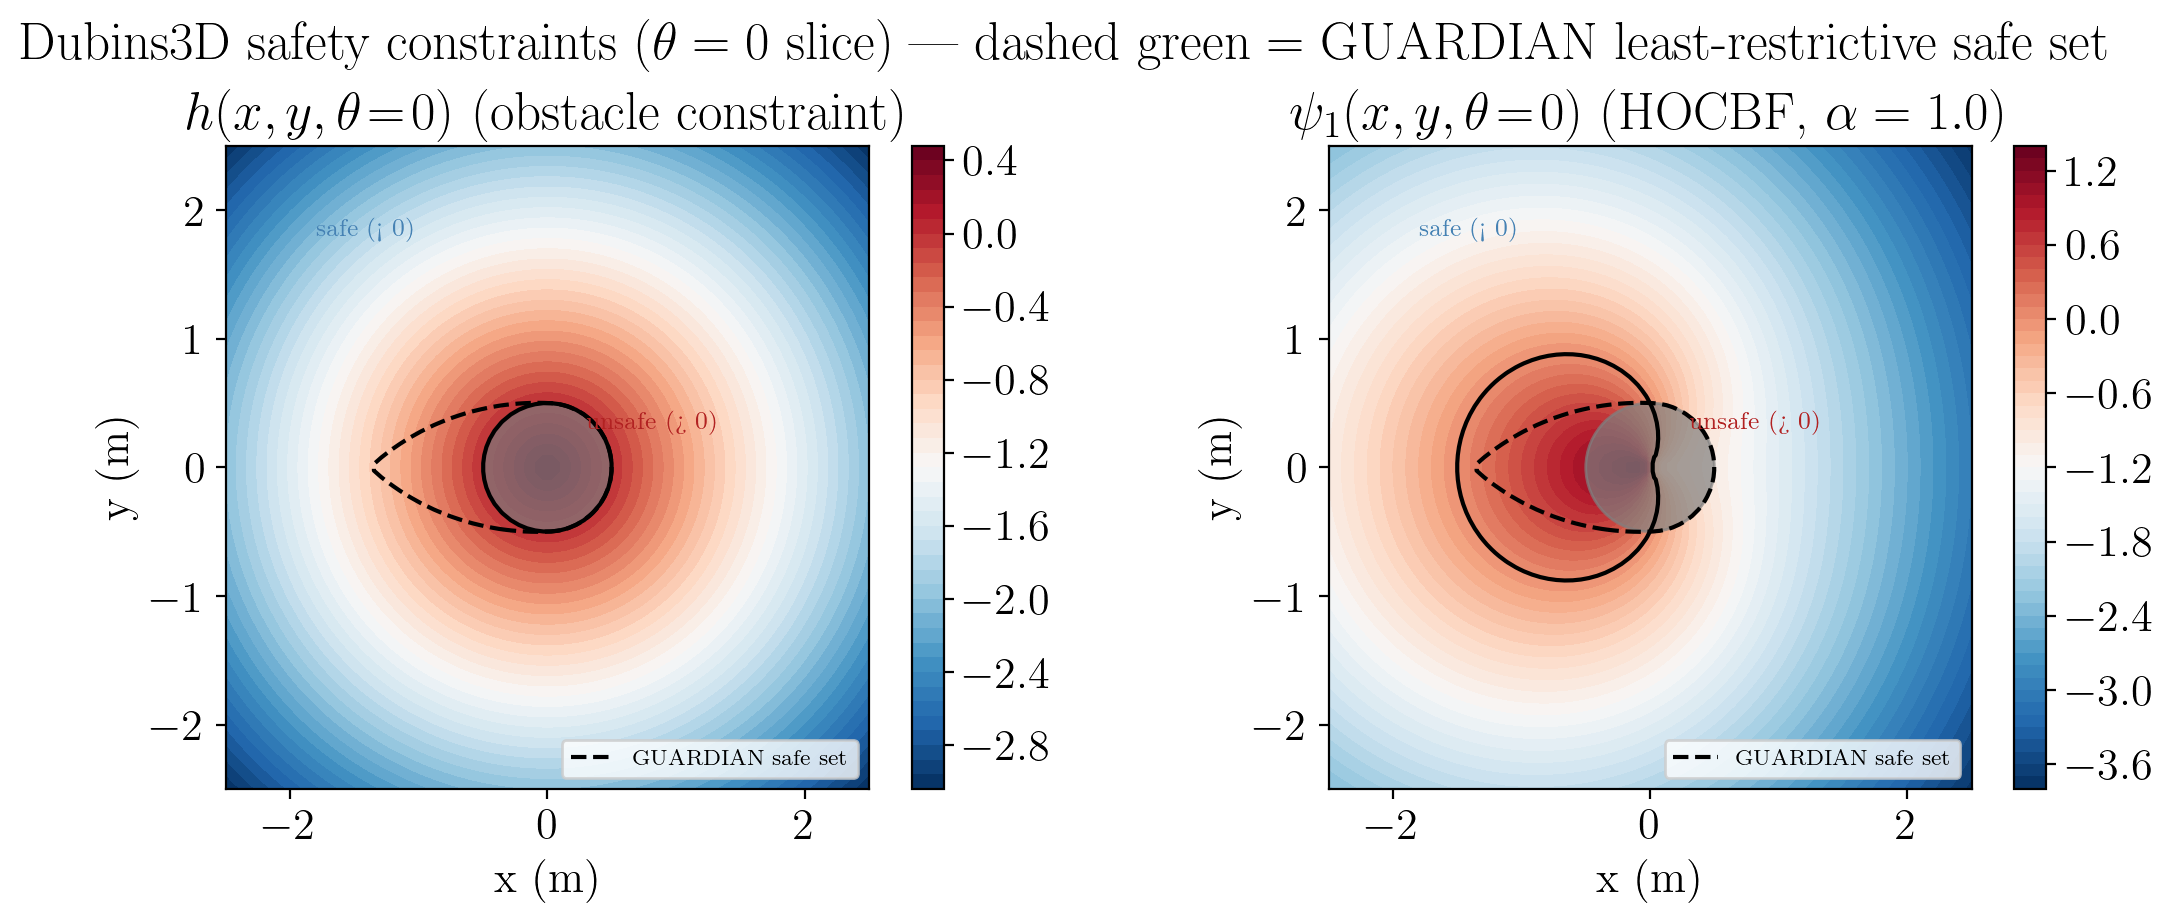

In [4]:
x0 = jnp.array(task.eq_state())   # (0, 0, 0)
f0 = task.f(x0)
G0 = task.G(x0)
h0 = task.h_components(x0)
B0 = task.handcbf_B(x0, hocbf_alpha)

print(f"Equilibrium state  x0 = {jax2np(x0)}")
print(f"Drift  f(x0)          = {jax2np(f0)}  (vel={task.VEL} m/s eastward at θ=0)")
print(f"Input  G(x0)          = {jax2np(G0).flatten()}")
print(f"h_components(x0)      = {jax2np(h0)}  (obstacle dist-r = {-float(h0[0]):.3f} m)")
print(f"handcbf_B(x0, α={hocbf_alpha}) = {jax2np(B0)}")

# ── Visualise h and ψ₁ over the xy plane (θ=0) ───────────────────────────────────────────
n = 80
xs_g = np.linspace(-2.5, 2.5, n)
ys_g = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(xs_g, ys_g)
x_grid = jnp.array(np.stack([XX.ravel(), YY.ravel(), np.zeros(n*n)], axis=1))

nh = task.nh
h_grid = jax2np(jax.vmap(task.h_components)(x_grid)).reshape(n, n, nh)
B_grid = jax2np(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x_grid)).reshape(n, n, nh)

# ── GUARDIAN (HJ) safe set: θ=0 slice using coordinate_vectors ─────────────────
hj_xs     = np.array(hj_grid.coordinate_vectors[0])   # (N_GRID,) x coords
hj_ys     = np.array(hj_grid.coordinate_vectors[1])   # (N_GRID,) y coords
theta_vec = np.array(hj_grid.coordinate_vectors[2])   # (N_GRID,) theta coords
theta_idx = int(np.argmin(np.abs(theta_vec)))          # index closest to theta=0
hj_slice  = np.array(hj_target_values[:, :, theta_idx])  # (N_GRID_x, N_GRID_y)

print(f"HJ slice at theta_idx={theta_idx} (theta={theta_vec[theta_idx]:.4f} rad)")
print(f"  value range: [{hj_slice.min():.3f}, {hj_slice.max():.3f}]")
print(f"  has zero crossing: {bool((hj_slice.min() < 0) & (hj_slice.max() > 0))}")

import matplotlib.lines as mlines
hj_proxy = mlines.Line2D([], [], color='k', linewidth=1.5,
                          linestyle='--', label='GUARDIAN safe set')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
for ax, Z, title in zip(axes,
                         [h_grid[:,:,0], B_grid[:,:,0]],
                         [r'$h(x,y,\theta\!=\!0)$  (obstacle constraint)',
                          rf'$\psi_1(x,y,\theta\!=\!0)$  (HOCBF, $\alpha={hocbf_alpha}$)']):
    cm = ax.contourf(XX, YY, Z, levels=50, cmap='RdBu_r')
    ax.contour(XX, YY, Z, levels=[0.0], colors='k', linewidths=1.5)
    fig.colorbar(cm, ax=ax)
    # GUARDIAN safe set boundary (least-restrictive safe set from HJ reachability)
    # contour(x1d, y1d, Z) expects Z[j,i]: Z[iy, ix] => transpose hj_slice
    ax.contour(hj_xs, hj_ys, hj_slice.T, levels=[0.0],
               colors='k', linewidths=1.5, linestyles='--')
    obs = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                     task.radius_obs, color='gray', alpha=0.7)
    ax.add_patch(obs)
    ax.set(title=title, xlabel='x (m)', ylabel='y (m)', aspect='equal',
           xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
    ax.annotate('safe (< 0)', xy=(-1.8, 1.8), color='steelblue', fontsize=9)
    ax.annotate('unsafe (> 0)', xy=(0.3, 0.3), color='firebrick', fontsize=9)
    ax.legend(handles=[hj_proxy], loc='lower right', fontsize=8)
plt.suptitle(rf'Dubins3D safety constraints ($\theta=0$ slice) — dashed green = GUARDIAN least-restrictive safe set')
plt.show()


## Nominal-policy rollouts

The nominal `nom_pol_goto` steers toward (2, 0) and drives straight through the obstacle when unconstrained.

## Hand-CBF safety filter

Apply the HOCBF `handcbf_B` (ψ₁ = L_f h + α h) via a min-norm QP.  Control appears in ψ̇₁, so the QP is feasible (relative degree 2 → 1 for ψ₁).

In [7]:
# ── A few challenging initial conditions ─────────────────────────────────────
x_ics = {
    # 'head-on':   jnp.array([-1.6,  -0.03,  0.0]),           # east, straight at obstacle
    'head-on':   jnp.array([-1.6,  -0.03,  0.0]),           # east, straight at obstacle
    'from below':jnp.array([-0.5, -1.5,  np.pi/2]),        # north from below
    'diagonal':  jnp.array([-1.2, -1.0,  np.pi/6]),        # NE approach
    'head-on+':  jnp.array([-1.6,  0.03,  0.0]),           # east, straight at obstacle, other side
}

# ── Rollout helper ────────────────────────────────────────────────────────────
def _make_rollout(step_fn):
    """Wrap step_fn(x, step_idx) → (x_next, x) into a JIT-compiled rollout."""
    def rollout(x0):
        _, xs = jax.lax.scan(step_fn, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)   # (T+1, nx)
    return jax.jit(rollout)

# ── Nominal step (no noise, no CBF) ──────────────────────────────────────────
def _nom_step(x, step_idx):
    u = task.nom_pol_goto(x)
    return x + DT * task.xdot(x, u), x

rollout_nom = _make_rollout(_nom_step)

# ── Hand-CBF step (perfect state estimate) ────────────────────────────────────
def _handcbf_step(x, step_idx):
    u_nom = task.nom_pol_goto(x)
    h_B   = task.handcbf_B(x, hocbf_alpha) + V_SHIFT
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(x), task.G(x), u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), x

rollout_handcbf = _make_rollout(_handcbf_step)


## Duality CBF — robust to measurement noise

With noisy state estimates the naive CBF may apply the wrong control.  The duality CBF finds the worst-case state inside the uncertainty box for each (constraint, direction) pair and passes all of them to a single QP.

In [8]:
# ── Constant bias noise model ─────────────────────────────────────────────────
# A single bias is sampled once per trajectory and added to every state estimate.
# More realistic than i.i.d. per-step noise for sensor offsets / GPS drift.
def _sample_bias(key):
    return jax.random.uniform(key, (task.NX,), minval=-STATE_EPS_DUAL, maxval=STATE_EPS_DUAL)

# ── Projected gradient ascent over a box ─────────────────────────────────────
def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    """Maximise scalar_fn over [lo, hi] via projected gradient ascent."""
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

# ── CBF ingredients: h, Lf h, LG h ───────────────────────────────────────────
def _cbf_ingredients(x):
    h  = task.handcbf_B(x, hocbf_alpha)
    hx = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x)
    return h, hx @ task.f(x), hx @ task.G(x)

# ── Image-set function for duality CBF ────────────────────────────────────────
# The image set is {(b(x), a(x)) : x in [xhat-eps, xhat+eps]} where:
#   a(x) = Lf B(x) + alpha * B(x)   (drift + barrier term)
#   b(x) = LG B(x)                   (control authority, scalar for nu=1)
# The CBF condition "b*u + a >= 0 for all x in uncertainty set" is equivalent to
# "min_{y in Conv(image set)} [u, 1] · y >= 0".

def _image_fn(x):
    """Returns (b, a) at state x — the image set coordinates."""
    h, Lf_h, LG_h = _cbf_ingredients(x)
    a = Lf_h[0] + ALPHA_QP * h[0]   # scalar: drift + alpha * barrier
    b = LG_h[0, 0]                   # scalar: control coefficient (nu=1)
    return jnp.array([b, a])          # (2,)

# ── Duality CBF formulation (arxiv 2603.26999) ───────────────────────────────
# 1. Over-approximate Conv(image set) as polytope {y : C_poly @ y <= d_poly}
#    via N supporting hyperplanes
# 2. Solve dual QP: min ||u - u_nom||^2 s.t. dual feasibility certifies
#    that the CBF holds for ALL states in the uncertainty set

N_PLANES_DUAL = 16    # number of supporting hyperplane directions on S^1 (2D image set → 6 suffices)
_DUAL_ANGLES  = jnp.linspace(-jnp.pi, jnp.pi, N_PLANES_DUAL, endpoint=False)
_DUAL_DIRS    = jnp.stack([jnp.cos(_DUAL_ANGLES), jnp.sin(_DUAL_ANGLES)], axis=1)  # (N, 2)

_NH = task.nh   # 1
_nu = task.nu   # 1
_u_lb_scalar = float(u_lb[0])   # concrete Python float, safe inside JIT
_u_ub_scalar = float(u_ub[0])

from jaxproxqp.jaxproxqp import JaxProxQP as _JaxProxQP
from jaxproxqp.qp_problems import QPModel as _QPModel

def _duality_cbf_qp(C_poly, d_poly, u_nom_scalar, u_lb_scalar, u_ub_scalar,
                     penalty=10.0, relax_eps=0.1):
    """
    Solve the duality-based CBF QP.

    Decision variables: z = [lambda_1..lambda_N, u, r]  (size N+2)
      - lambda >= 0: dual variables for polytope constraints
      - u: control input
      - r: relaxation variable (r <= 0 means constraint is not relaxed)

    Objective: min 0.5 * u^2 - u_nom * u + penalty/2 * (r - relax_eps)^2

    Equality:  C_poly^T @ lambda = [u, 1]^T   (h<0 safe → max<=0 duality)
               => C_poly^T @ lambda - [u; 0] = [0; 1]

    Inequality: d_poly^T @ lambda - r <= 0   (CBF feasibility certificate)

    Bounds: lambda >= 0, u_lb <= u <= u_ub, r >= -relax_eps
    """
    N = C_poly.shape[0]
    n = N + 2   # [lambda(N), u(1), r(1)]
    dtype = jnp.float32

    # ── Objective ─────────────────────────────────────────────────────────────
    H = jnp.zeros((n, n), dtype=dtype)
    H = H.at[N, N].set(1.0)              # u^2 term
    H = H.at[N+1, N+1].set(penalty)      # r^2 term

    g = jnp.zeros(n, dtype=dtype)
    g = g.at[N].set(-u_nom_scalar)        # -u_nom * u
    g = g.at[N+1].set(penalty * relax_eps)   # pushes r toward -relax_eps (tighter than needed = safe default)

    # ── Equality: C_poly^T @ lambda - [1;0] * u = [0; 1]  (h<0 safe convention) ──
    # A_eq @ z = b_eq
    # A_eq is (2, N+2)
    A_eq = jnp.zeros((2, n), dtype=dtype)
    A_eq = A_eq.at[:, :N].set(C_poly.T)       # (2, N)
    A_eq = A_eq.at[0, N].set(-1.0)             # C^T λ - u = 0  (from C^T λ = [u; 1])
    # r has no role in equality constraints (column N+1 stays 0)
    b_eq = jnp.array([0.0, 1.0], dtype=dtype)   # C^T λ = [u; 1] → second component = 1

    # ── Inequality: d^T @ lambda - r <= 0  ────────────────────────────────────
    # C_ineq @ z <= u_ineq, l_ineq <= C_ineq @ z
    C_ineq = jnp.zeros((1, n), dtype=dtype)
    C_ineq = C_ineq.at[0, :N].set(d_poly)
    C_ineq = C_ineq.at[0, N+1].set(-1.0)      # -r
    l_ineq = jnp.array([-1e8], dtype=dtype)
    u_ineq = jnp.array([0.0], dtype=dtype)

    # ── Variable bounds ───────────────────────────────────────────────────────
    l_box = jnp.concatenate([
        jnp.zeros(N, dtype=dtype),             # lambda >= 0
        jnp.array([u_lb_scalar], dtype=dtype), # u >= u_lb
        jnp.array([-relax_eps], dtype=dtype),  # r >= -relax_eps
    ])
    u_box = jnp.concatenate([
        jnp.full(N, 1e8, dtype=dtype),         # lambda <= big
        jnp.array([u_ub_scalar], dtype=dtype), # u <= u_ub
        jnp.full(1, 1e8, dtype=dtype),         # r <= big
    ])

    qp = _QPModel(H, g, A_eq, C_ineq, b_eq, u_ineq, l_ineq, u_box, l_box)
    settings = _JaxProxQP.Settings.default()
    sol = _JaxProxQP(qp, settings).solve()
    u_opt = sol.x[N]
    r_opt = sol.x[N+1]
    return u_opt, r_opt, sol


# ── Step functions — carry = (x_true, bias) ───────────────────────────────────
# bias is sampled once before the rollout; xhat = x_true + bias every step.

def _nom_noisy_step(carry, step_idx):
    x, bias = carry
    xhat = x + bias
    u    = task.nom_pol_goto(xhat)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

def _cbf_noisy_step(carry, step_idx):
    """Naive hand-CBF applied at biased estimate — no bias awareness."""
    x, bias = carry
    xhat  = x + bias
    h_B   = task.handcbf_B(xhat, hocbf_alpha) + V_SHIFT
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat)
    u_nom = task.nom_pol_goto(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

def _duality_step(carry, step_idx):
    """Duality CBF (arxiv 2603.26999): robust to ENTIRE uncertainty set via LP duality."""
    x, bias = carry
    xhat  = x + bias
    lo    = xhat - STATE_EPS_DUAL
    hi    = xhat + STATE_EPS_DUAL
    u_nom = task.nom_pol_goto(xhat)

    # Random keys for projected gradient ascent (one per hyperplane direction)
    opt_key  = jax.random.fold_in(BASE_KEY, step_idx)
    all_keys = jax.random.split(opt_key, N_PLANES_DUAL)

    def _support_one(d_vec, k_j):
        """Compute support function of image set in direction d_vec."""
        def _obj(xi):
            img = _image_fn(xi)       # (2,) = [b(x), a(x)]
            return d_vec @ img         # scalar: d1*b + d2*a
        val, _ = proj_grad_max_box(_obj, lo, hi, n_restarts=2, n_steps=15, lr=0.05, key=k_j)
        return val                     # scalar: max_{x in box} d^T image(x)

    # C_poly[i] = direction_i, d_poly[i] = support value in that direction
    # This gives the H-polytope {y : C_poly @ y <= d_poly} ⊇ Conv(image set)
    d_poly = jax.vmap(_support_one)(_DUAL_DIRS, all_keys)  # (N,)
    C_poly = _DUAL_DIRS                                     # (N, 2)

    u_opt, r_opt, _ = _duality_cbf_qp(
        C_poly, d_poly,
        u_nom[0], _u_lb_scalar, _u_ub_scalar,
        penalty=10.0, relax_eps=0.1
    )
    u = jnp.array([u_opt])
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

# ── Rollout wrapper: rollout(x0, bias) → (xs_full, xhats) ────────────────────
def _make_noisy_rollout(step_fn):
    def rollout(x0, bias):
        _, (xs, xhats) = jax.lax.scan(step_fn, (x0, bias), jnp.arange(T))
        xs_full = jnp.concatenate([x0[None], xs], axis=0)
        return xs_full, xhats
    return jax.jit(rollout)

rollout_nom_noisy = _make_noisy_rollout(_nom_noisy_step)
rollout_cbf_noisy = _make_noisy_rollout(_cbf_noisy_step)
rollout_duality   = _make_noisy_rollout(_duality_step)

print(f"Duality: {_NH} constraint x {N_PLANES_DUAL} directions = {_NH*N_PLANES_DUAL} pairs")
print("Compiling...")
x_test    = jnp.array(list(x_ics.values())[0])
bias_test = _sample_bias(BASE_KEY)
rollout_nom_noisy(x_test, bias_test); print("  nom+noise done")
rollout_cbf_noisy(x_test, bias_test); print("  CBF+noise done")
rollout_duality(x_test, bias_test);   print("  duality done")
# ── R-CBF-QP step function ────────────────────────────────────────────────────
# Samples N random states from the uncertainty box, computes gammas that bound
# the worst-case CBF constraint error, then solves a tightened QP.
N_RCBF_SAMPLES = 20

def _rcbf_step(carry, step_idx):
    """R-CBF-QP: sample-based tightening over the uncertainty box."""
    x, bias = carry
    xhat = x + bias
    lo   = xhat - STATE_EPS_DUAL
    hi   = xhat + STATE_EPS_DUAL

    samp_key = jax.random.fold_in(BASE_KEY, step_idx)
    x_pert   = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, task.NX)) * (hi - lo)

    _h_fn  = lambda xi: task.handcbf_B(xi, hocbf_alpha)
    _hx_fn = jax.jacobian(_h_fn)

    h_V_nom   = _h_fn(xhat)
    hx_Vx_nom = _hx_fn(xhat)
    u_nom     = task.nom_pol_goto(xhat)

    h_V_pert   = jax.vmap(_h_fn)(x_pert)                  # (N, nh)
    hx_Vx_pert = jax.vmap(_hx_fn)(x_pert)                 # (N, nh, nx)
    f_pert     = jax.vmap(task.f)(x_pert)                  # (N, nx)
    G_pert     = jax.vmap(task.G)(x_pert)                  # (N, nx, nu)
    u_nom_pert = jax.vmap(task.nom_pol_goto)(x_pert)       # (N, nu)

    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=task.f(xhat), G_nom=task.G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert,
        n_grid=200,
    )
    # gamma1, gamma2 = 1.0, 1.0
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, task.f(xhat), task.G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

rollout_rcbf = _make_noisy_rollout(_rcbf_step)
rollout_rcbf(x_test, bias_test)
print("  R-CBF-QP done")


# ── R-CBF fixed-gamma variants ───────────────────────────────────────────────
def _make_rcbf_fixed_step(gamma_val):
    """Create an R-CBF step function with fixed gamma1 = gamma2 = gamma_val."""
    def _rcbf_fixed_step(carry, step_idx):
        x, bias = carry
        xhat = x + bias
        _h_fn  = lambda xi: task.handcbf_B(xi, hocbf_alpha)
        _hx_fn = jax.jacobian(_h_fn)
        h_V_nom   = _h_fn(xhat)
        hx_Vx_nom = _hx_fn(xhat)
        u_nom     = task.nom_pol_goto(xhat)
        u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                                  h_V_nom, hx_Vx_nom, task.f(xhat), task.G(xhat), u_nom,
                                  gamma1=gamma_val, gamma2=gamma_val, relax_eps2=0.1)
        return (x + DT * task.xdot(x, u), bias), (x, xhat)
    return _rcbf_fixed_step

rollout_rcbf_02 = _make_noisy_rollout(_make_rcbf_fixed_step(0.2))
rollout_rcbf_10 = _make_noisy_rollout(_make_rcbf_fixed_step(1.0))
rollout_rcbf_02(x_test, bias_test)
print("  R-CBF (gamma=0.2) done")
rollout_rcbf_10(x_test, bias_test)
print("  R-CBF (gamma=1.0) done")

# # ── MR-CBF (Lipschitz-based tightening, cvxpy formulation) ───────────────────
# import cvxpy as cp

# # Raw (unclipped) constraint for MR-CBF Lipschitz estimation.
# # poly4_clip_max_flat uses jnp.minimum which creates a C1-but-not-C2 kink,
# # making the Lipschitz constant of Lf_B unbounded at the clip boundary.
# # The raw distance-based constraint is smooth everywhere outside the obstacle.
# def _h_components_raw(state):
#     x, y, theta = task.chk_x(state)
#     h_obs = -(jnp.sqrt((x - task.pos_obs[0])**2 + (y - task.pos_obs[1])**2)
#               - task.radius_obs)
#     return jnp.array([h_obs])

# def _handcbf_B_raw(state, alpha):
#     from mrncbf.utils.hocbf import hocbf
#     return hocbf(_h_components_raw, task.f, alpha0=alpha, state=state)

# # Lipschitz constants: per-dimension partial Lipschitz constants.
# # For a function g(x), the bound is |g(x) - g(x̂)| ≤ Σ_i L_i |x_i - x̂_i|
# # where L_i = max |∂g/∂x_i|.
# def _estimate_lipschitz_per_dim(n_samples=5000, margin=0.15):
#     """Estimate per-dimension Lipschitz constants of Lf_B, LG_B, alpha*B.
    
#     Only samples states outside the obstacle (with `margin` clearance beyond
#     the obstacle radius) to avoid singularity-inflated estimates.
#     """
#     rng = np.random.default_rng(123)
#     lb = np.array(task.train_bounds()[0])
#     ub = np.array(task.train_bounds()[1])
#     # Oversample, then filter to states safely outside the obstacle
#     n_cand = n_samples * 5
#     xs_cand = lb + rng.random((n_cand, task.NX)) * (ub - lb)
#     dist = np.sqrt((xs_cand[:, 0] - float(task.pos_obs[0]))**2 +
#                    (xs_cand[:, 1] - float(task.pos_obs[1]))**2)
#     outside = dist > (task.radius_obs + margin)
#     xs = xs_cand[outside][:n_samples]
#     print(f"  Lipschitz sampling: {outside.sum()}/{n_cand} outside obstacle, using {len(xs)}")

#     _h_fn  = jax.jit(lambda xi: _handcbf_B_raw(xi, hocbf_alpha))
#     _hx_fn = jax.jit(jax.jacobian(_h_fn))

#     _ingredients_vmap = jax.jit(jax.vmap(lambda xi: jnp.concatenate([
#         _h_fn(xi),
#         _hx_fn(xi) @ task.f(xi),
#         (_hx_fn(xi) @ task.G(xi)).reshape(-1)
#     ])))

#     vals = jax2np(_ingredients_vmap(jnp.array(xs, dtype=jnp.float32)))
#     nh = task.nh
#     # cols: h(0:nh), Lf(nh:2*nh), LG(2*nh:)

#     delta = 1e-3
#     # Per-dimension max partial derivative for each ingredient
#     L_h_dim  = np.zeros(task.NX)
#     L_Lf_dim = np.zeros(task.NX)
#     L_LG_dim = np.zeros(task.NX)
#     obs_x, obs_y = float(task.pos_obs[0]), float(task.pos_obs[1])
#     r_safe = task.radius_obs + margin
#     for dim in range(task.NX):
#         xs_p = xs.copy()
#         xs_p[:, dim] += delta
#         # Exclude pairs where the perturbed point lands inside the obstacle
#         dist_p = np.sqrt((xs_p[:, 0] - obs_x)**2 + (xs_p[:, 1] - obs_y)**2)
#         safe = dist_p > r_safe
#         vals_p = jax2np(_ingredients_vmap(jnp.array(xs_p, dtype=jnp.float32)))
#         dv = np.abs(vals_p - vals) / delta
#         L_h_dim[dim]  = dv[safe, :nh].max()
#         L_Lf_dim[dim] = dv[safe, nh:2*nh].max()
#         L_LG_dim[dim] = dv[safe, 2*nh:].max()
#     return L_h_dim, L_Lf_dim, L_LG_dim

# L_h_dim, L_Lf_dim, L_LG_dim = _estimate_lipschitz_per_dim()
# L_alphah_dim = ALPHA_QP * L_h_dim
# print(f"Per-dim Lipschitz constants:")
# for i, lbl in enumerate(['x', 'y', 'theta']):
#     print(f"  {lbl}: L_Lf={L_Lf_dim[i]:.3f}  L_LG={L_LG_dim[i]:.3f}  L_ah={L_alphah_dim[i]:.3f}")

# def _mrcbf_rollout(x0, bias):
#     """MR-CBF rollout using cvxpy (Python loop, not JIT-able)."""
#     x = np.array(x0, dtype=np.float64)
#     bias_np = np.array(bias, dtype=np.float64)
#     xs = [x.copy()]
#     xhats = []

#     _h_fn  = lambda xi: task.handcbf_B(xi, hocbf_alpha)
#     _hx_fn = jax.jacobian(_h_fn)
#     eps_np = np.array(STATE_EPS_DUAL, dtype=np.float64)

#     # Per-dimension tightening: sum_i eps_i * L_i for each ingredient
#     tight_Lf  = float(np.sum(eps_np * L_Lf_dim))
#     tight_ah  = float(np.sum(eps_np * L_alphah_dim))
#     tight_LG  = float(np.sum(eps_np * L_LG_dim))

#     for t in range(T):
#         xhat = x + bias_np
#         xhats.append(xhat.copy())
#         xhat_jnp = jnp.array(xhat, dtype=jnp.float32)

#         h_B  = float(jax2np(_h_fn(xhat_jnp))[0])
#         hx_B = jax2np(_hx_fn(xhat_jnp))[0]  # (nx,)
#         f_val = jax2np(task.f(xhat_jnp))
#         G_val = jax2np(task.G(xhat_jnp))

#         Lf_B = float(hx_B @ f_val)
#         LG_B = float((hx_B @ G_val).flatten()[0])

#         u_nom = float(jax2np(task.nom_pol_goto(xhat_jnp))[0])

#         # MR-CBF QP: min (u - u_nom)^2
#         # s.t. Lf_B + LG_B*u + alpha*h_B
#         #      - (tight_Lf + tight_ah) - tight_LG*|u| >= 0
#         #      u_lb <= u <= u_ub
#         u_var = cp.Variable(1)
#         objective = cp.Minimize((u_var[0] - u_nom) ** 2)
#         constraints = [
#             Lf_B + LG_B * u_var[0] + ALPHA_QP * h_B
#             - (tight_Lf + tight_ah)
#             - tight_LG * cp.abs(u_var[0]) >= 0,
#             u_var[0] >= float(u_lb[0]),
#             u_var[0] <= float(u_ub[0]),
#         ]
#         prob = cp.Problem(objective, constraints)
#         try:
#             prob.solve(warm_start=True, solver=cp.SCS)
#             u = u_var.value[0] if u_var.value is not None else u_nom
#         except Exception:
#             u = u_nom

#         u_jnp = jnp.array([u], dtype=jnp.float32)
#         x = np.array(jax2np(jnp.array(x, dtype=jnp.float32) + DT * task.xdot(jnp.array(x, dtype=jnp.float32), u_jnp)))
#         xs.append(x.copy())

#     xs_full = jnp.array(np.stack(xs))
#     xhats_arr = jnp.array(np.stack(xhats))
#     return xs_full, xhats_arr

# # Quick test
# _mr_xs, _mr_xh = _mrcbf_rollout(x_test, bias_test)
# print(f"  MR-CBF done (Python loop, {T} steps)")


Duality: 1 constraint x 16 directions = 16 pairs
Compiling...
  nom+noise done


2026-07-19 10:18:29.536 | DEBUG    | jaxproxqp.settings:default:62 - Using default settings for float32


  CBF+noise done
  duality done
  R-CBF-QP done
  R-CBF (gamma=0.2) done
  R-CBF (gamma=1.0) done


## NMR-CBF: Neural Measurement-Robust CBF

The duality CBF runs `proj_grad_max_box` at every timestep — expensive at ~10 s per trajectory.
We can **amortise** this by learning a small correction network φ(x̂) that predicts, for each
constraint *i*, the worst-case increase in (L_f h_i + α h_i) over the uncertainty box:

$$\phi_i(\hat x) \approx \max_{x \in [\hat x - \varepsilon,\,\hat x + \varepsilon]}
\bigl(L_f h_i(x) + \alpha\, h_i(x)\bigr) - \bigl(L_f h_i(\hat x) + \alpha\, h_i(\hat x)\bigr)$$

At runtime the NMR-CBF simply tightens the barrier: $h_i^{\text{tight}} = h_i(\hat x) + \phi_i(\hat x)/\alpha$,
replacing the online optimisation with a single MLP forward pass.


Computing phi labels for training set...
Computing phi labels for test set...
Label stats  mean=0.3613  std=0.4099  max=5.0000
Fraction non-zero: 99.84%


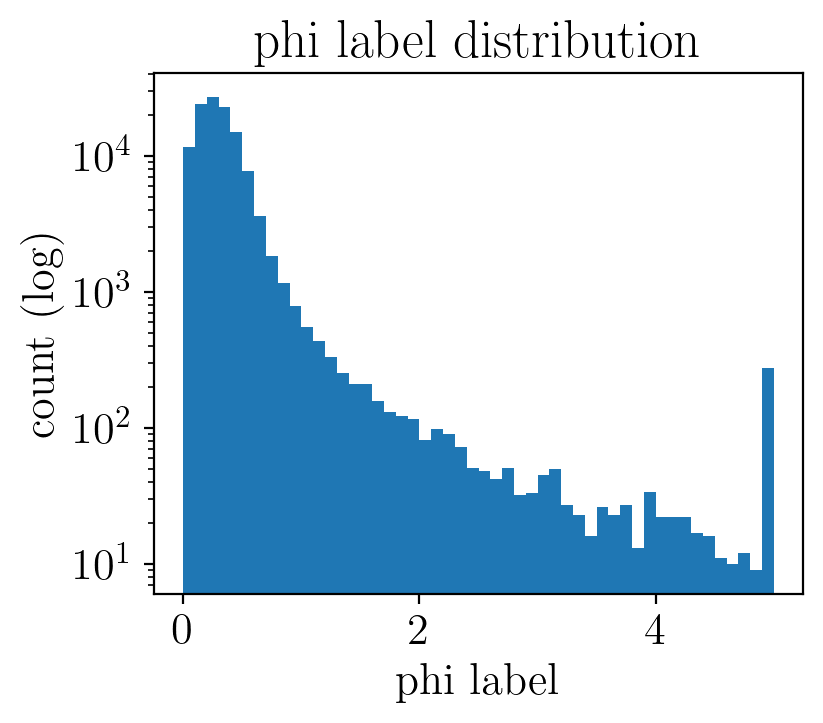

In [7]:
# ── φ label oracle: worst-case correction over uncertainty box ────────────────
PHI_MAX = 5.0   # cap labels against outliers near obstacle boundary

@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, eps, key, n_restarts=4, n_steps=30, lr=0.05):
    """φ_i(x̂, ε) = max_{x in [x̂-ε, x̂+ε]} (Lf h_i + α h_i)(x) - (Lf h_i + α h_i)(x̂), clipped ≥ 0."""
    lo = xhat - eps
    hi = xhat + eps

    h_nom   = task.handcbf_B(xhat, hocbf_alpha)
    Lf_nom  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat) @ task.f(xhat)
    nom_val = Lf_nom + ALPHA_QP * h_nom   # (nh,)

    def worst_i(i, k):
        def obj(x):
            h  = task.handcbf_B(x, hocbf_alpha)
            Lf = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x) @ task.f(x)
            return (Lf + ALPHA_QP * h)[i]
        _, x_wc  = proj_grad_max_box(obj, lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = task.handcbf_B(x_wc, hocbf_alpha)
        Lf_wc = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x_wc) @ task.f(x_wc)
        delta = (Lf_wc + ALPHA_QP * h_wc)[i] - nom_val[i]
        return jnp.clip(delta, 0.0, PHI_MAX)

    keys = jax.random.split(key, _NH)
    return jax.vmap(worst_i)(jnp.arange(_NH), keys)

# ── Generate training / test datasets ─────────────────────────────────────────
# Sample x̂ uniformly over the full state space. Points far from the obstacle
# will have φ ≈ 0; the network will learn to be non-zero only near the boundary.
# eps is sampled per-dimension from Uniform[0, EPS_MAX] so the network generalises
# across different uncertainty levels.
lb = jnp.array(task.train_bounds()[0])   # (-2.5, -2.5, -π)
ub = jnp.array(task.train_bounds()[1])   # ( 2.5,  2.5,  π)

N_TRAIN, N_TEST = 120000, 30000
# N_TRAIN, N_TEST = 12000, 3000
rng_phi         = jax.random.PRNGKey(7)
rng_phi, rng_tr, rng_te, rng_eps_tr, rng_eps_te = jax.random.split(rng_phi, 5)

xhat_train = lb + jax.random.uniform(rng_tr, (N_TRAIN, task.NX)) * (ub - lb)
xhat_test  = lb + jax.random.uniform(rng_te, (N_TEST,  task.NX)) * (ub - lb)

# Per-sample eps ~ Uniform[0, EPS_MAX] for each dimension
eps_train = jax.random.uniform(rng_eps_tr, (N_TRAIN, task.NX)) * EPS_MAX
eps_test  = jax.random.uniform(rng_eps_te, (N_TEST,  task.NX)) * EPS_MAX

keys_tr = jax.random.split(rng_phi,              N_TRAIN)
keys_te = jax.random.split(jax.random.PRNGKey(99), N_TEST)

print('Computing phi labels for training set...')
phi_train = jax.vmap(phi_true_fn)(xhat_train, eps_train, keys_tr)   # (N_TRAIN, nh)
print('Computing phi labels for test set...')
phi_test  = jax.vmap(phi_true_fn)(xhat_test,  eps_test,  keys_te)

phi_tr_np = jax2np(phi_train)
print(f'Label stats  mean={phi_tr_np.mean():.4f}  std={phi_tr_np.std():.4f}'
      f'  max={phi_tr_np.max():.4f}')
print(f'Fraction non-zero: {(phi_tr_np > 0).mean():.2%}')

# ── Quick sanity: label distribution histogram ────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3.5), layout='constrained')
ax.hist(phi_tr_np.ravel(), bins=50, log=True)
ax.set(xlabel='phi label', ylabel='count (log)', title='phi label distribution')
plt.show()


PhiNet: 1313 parameters  (input=2*3=6, output=1)
Loaded NMR-CBF weights from ../../runs/nmr_cbf_dubins3d/32x32/noclip/phi_params.pkl


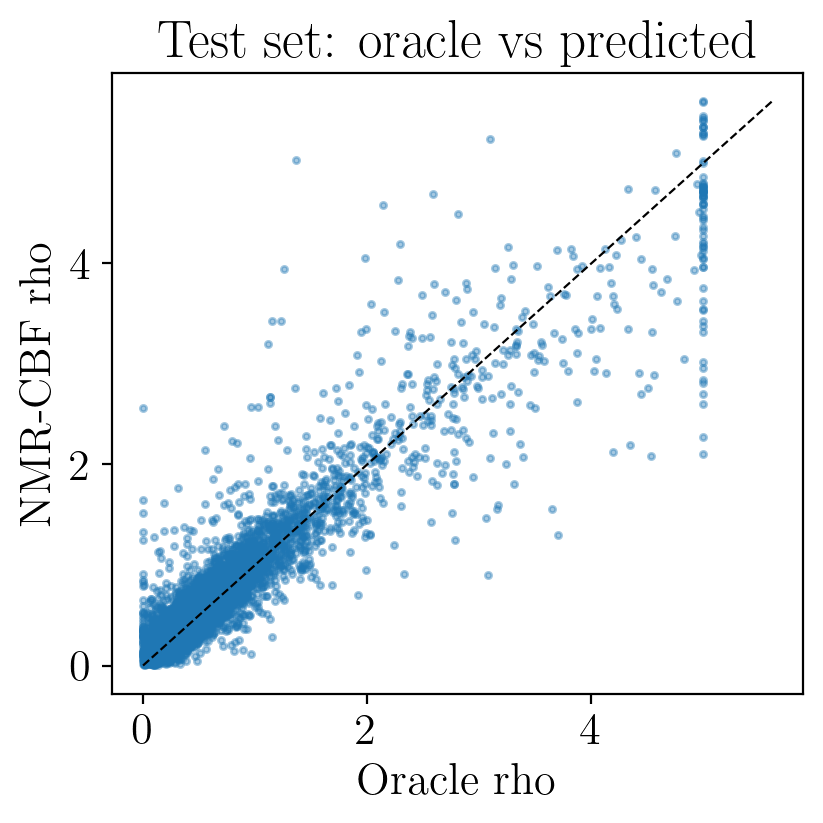

In [8]:
# ── PhiNet definition: input = (xhat, eps) ────────────────────────────────────
import os, pickle
from pathlib import Path

class PhiNet(nn.Module):
    if NMR_WEIGHTS_DIR[-5:] == "32x32":
        hidden_dims: tuple = (32, 32)
    elif NMR_WEIGHTS_DIR[-5:] == "64x64":
        hidden_dims: tuple = (64, 64)
    else:
        hidden_dims: tuple = (32, 32)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat, eps):
        h = jnp.concatenate([xhat, eps])   # (2*nx,)
        for d in self.hidden_dims:
            h = nn.tanh(nn.Dense(d)(h))
        return nn.softplus(nn.Dense(self.n_constraints)(h))   # phi >= 0

phi_net    = PhiNet()
phi_params = phi_net.init(jax.random.PRNGKey(0),
                          jnp.zeros(task.NX), jnp.zeros(task.NX))['params']
n_params   = sum(p.size for p in jax.tree_util.tree_leaves(phi_params))
print(f'PhiNet: {n_params} parameters  (input=2*{task.NX}={2*task.NX}, output={_NH})')

# ── Load or train ────────────────────────────────────────────────────────────
_nmr_dir = Path(NMR_WEIGHTS_DIR) if NMR_WEIGHTS_DIR else None
_nmr_weights_file = _nmr_dir / 'phi_params.pkl' if _nmr_dir else None

if _nmr_weights_file and _nmr_weights_file.exists():
    with open(_nmr_weights_file, 'rb') as _f:
        phi_params = pickle.load(_f)
    print(f'Loaded NMR-CBF weights from {_nmr_weights_file}')
else:
    optimizer = optax.adam(3e-3)
    opt_state = optimizer.init(phi_params)

    BATCH_SIZE = 256
    N_EPOCHS   = 500

    @jax.jit
    def train_step(params, opt_state, xb, eps_b, phi_b):
        def loss_fn(p):
            pred = jax.vmap(lambda x, e: phi_net.apply({'params': p}, x, e))(xb, eps_b)
            return jnp.mean((pred - phi_b) ** 2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss

    rng_ep = jax.random.PRNGKey(42)
    losses = []
    for epoch in range(N_EPOCHS):
        rng_ep, rng_shuf = jax.random.split(rng_ep)
        perm = jax.random.permutation(rng_shuf, N_TRAIN)
        for b in range(0, N_TRAIN, BATCH_SIZE):
            idx  = perm[b : b + BATCH_SIZE]
            phi_params, opt_state, ep_loss = train_step(
                phi_params, opt_state, xhat_train[idx], eps_train[idx], phi_train[idx])
        losses.append(float(ep_loss))
        if (epoch + 1) % 100 == 0:
            pred_val  = jax.vmap(lambda x, e: phi_net.apply({'params': phi_params}, x, e))(
                xhat_test, eps_test)
            val_mse   = float(jnp.mean((pred_val - phi_test) ** 2))
            print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

    fig, ax = plt.subplots(figsize=(6, 3), layout='constrained')
    ax.semilogy(losses)
    ax.set(xlabel='epoch', ylabel='MSE loss', title='PhiNet training')
    plt.show()

    # ── Save weights ──────────────────────────────────────────────────────────
    if _nmr_dir:
        _nmr_dir.mkdir(parents=True, exist_ok=True)
        with open(_nmr_weights_file, 'wb') as _f:
            pickle.dump(phi_params, _f)
        print(f'Saved NMR-CBF weights to {_nmr_weights_file}')

# ── Scatter: oracle vs predicted phi on test set ──────────────────────────────
pred_test = jax2np(jax.vmap(lambda x, e: phi_net.apply({'params': phi_params}, x, e))(
    xhat_test, eps_test))
fig, ax = plt.subplots(figsize=(4, 4), layout='constrained')
ax.scatter(jax2np(phi_test[:, 0]), pred_test[:, 0], s=5, alpha=0.4)
lim = max(jax2np(phi_test).max(), pred_test.max())
ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
ax.set(xlabel='Oracle rho', ylabel='NMR-CBF rho', title='Test set: oracle vs predicted')
plt.show()


In [9]:
# ── NMR-CBF step function ─────────────────────────────────────────────────────
_phi_params_frozen = phi_params   # snapshot after training

def _nmr_cbf_step(carry, step_idx):
    """NMR-CBF: tighten barrier by learned phi, no online optimisation."""
    x, bias = carry
    xhat  = x + bias
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat, STATE_EPS_DUAL)   # (nh,)
    h_B   = task.handcbf_B(xhat, hocbf_alpha) + phi / ALPHA_QP   # tightened
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat)
    u_nom = task.nom_pol_goto(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

rollout_nmr_cbf = _make_noisy_rollout(_nmr_cbf_step)
bias_test_compile = _sample_bias(BASE_KEY)
x_test_compile    = jnp.array(list(x_ics.values())[0])
rollout_nmr_cbf(x_test_compile, bias_test_compile)
print('NMR-CBF compiled.')


NMR-CBF compiled.


## GUARDIAN: HJ Reachability-based Uncertainty-Aware Filter

GUARDIAN uses Hamilton-Jacobi reachability analysis to compute a value function over the state space,
then at runtime evaluates worst-case next states over the uncertainty box against that value function
to pick the safest control input.

In [10]:
# ── GUARDIAN: uncertainty-aware filter ───────────────────────────────────────
from hjnnv import hjnnvUncertaintyAwareFilter

def estimation_function(obs):
    return obs   # identity estimator

guardian_filter = hjnnvUncertaintyAwareFilter(
    dynamics=hj_dynamics,
    pred_model=estimation_function,
    grid=hj_grid,
    initial_values=hj_initial_values,
    num_controls=30,
    num_disturbances=3,
    time_horizon=5.0
)

# ── GUARDIAN step function ────────────────────────────────────────────────────
def _guardian_step(carry, step_idx):
    """GUARDIAN: HJ reachability filter over uncertainty box."""
    x, bias = carry
    xhat = x + bias
    state_bounds = hj.sets.Box(xhat - STATE_EPS_DUAL, xhat + STATE_EPS_DUAL)
    u_nom = task.nom_pol_goto(xhat)

    _, u_star, _, val_filter, _, _, _, _ = guardian_filter.ua_filter_best_u(
        u_nom, state_bounds, num_states=5, delta=1.0
    )
    u = jnp.where(val_filter < 0.0, u_star, u_nom)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

rollout_guardian = _make_noisy_rollout(_guardian_step)
rollout_guardian(x_test_compile, bias_test_compile)
print('GUARDIAN compiled.')


100%|##########|  5.0000/5.0 [00:01<00:00,  4.83sim_s/s]


GUARDIAN compiled.


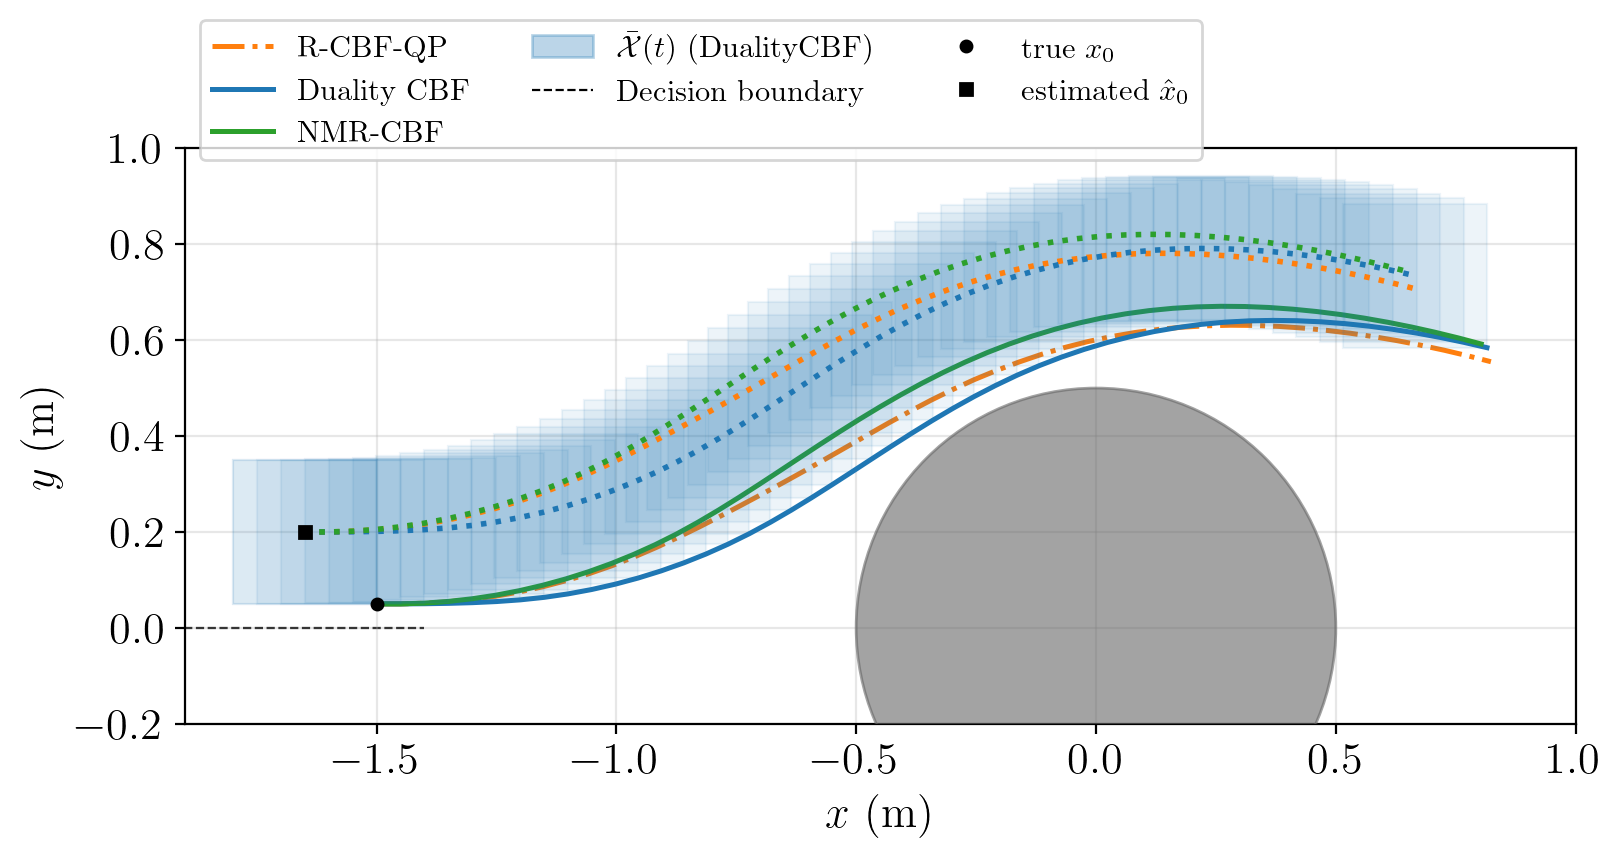

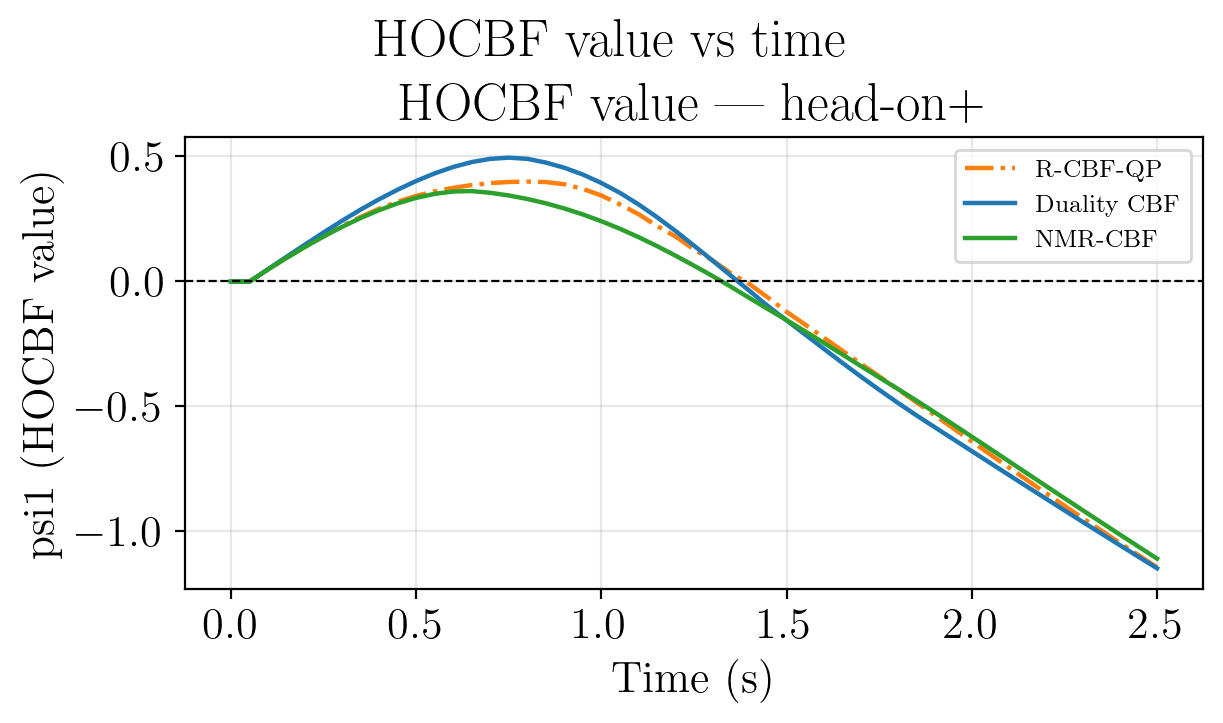

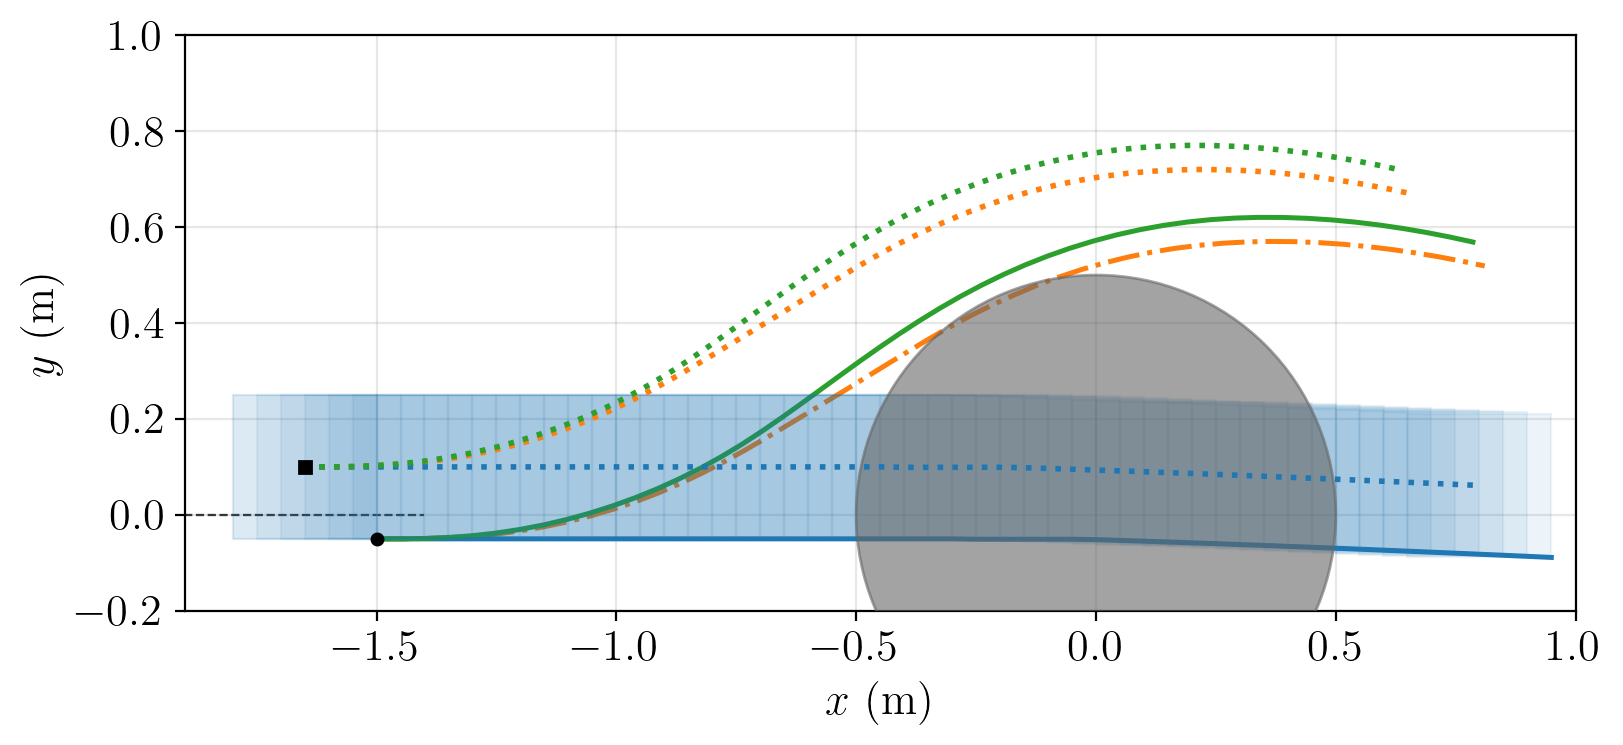

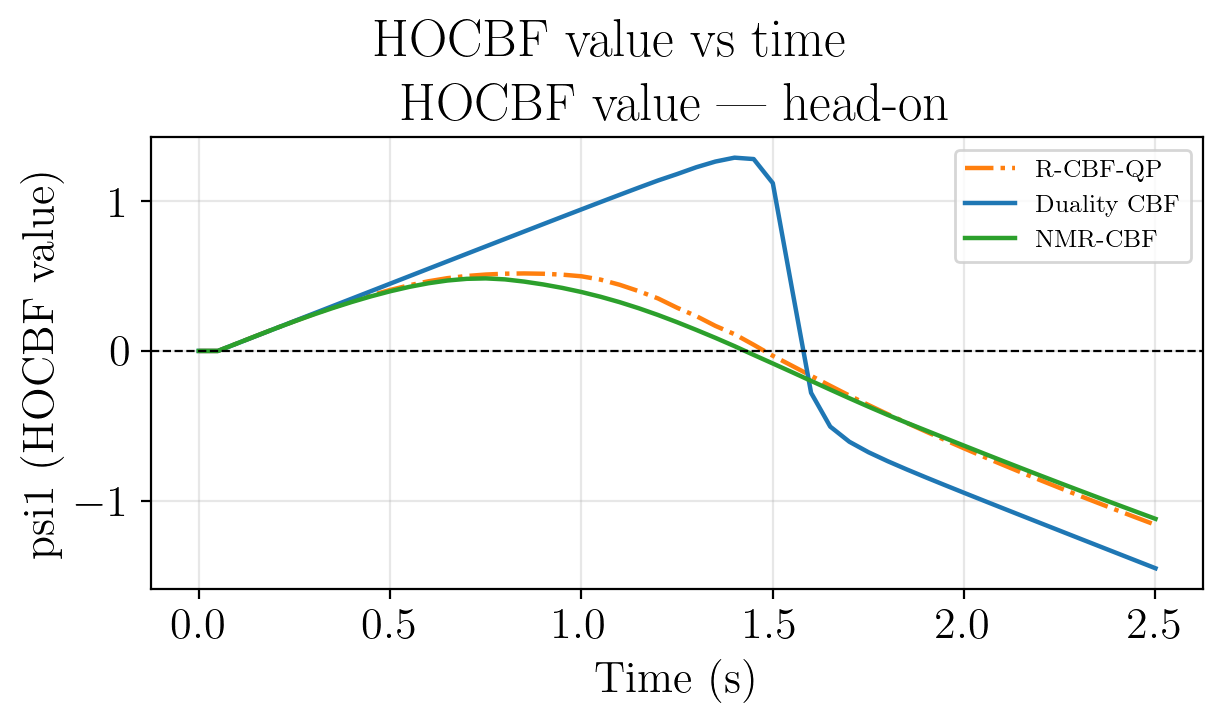

In [12]:
x_ics = {
    # 'head-on':   jnp.array([-1.6,  -0.03,  0.0]),           # east, straight at obstacle
    'head-on':   jnp.array([-1.5,  -0.05,  0.0]),           # east, straight at obstacle
    'head-on+':  jnp.array([-1.5,  0.05,  0.0]),           # east, straight at obstacle, other side
}

# ── Sample one fixed bias per IC (same bias for all three policies on each IC)
bias_per_ic = {
    name: _sample_bias(jax.random.fold_in(BASE_KEY, i))
    for i, name in enumerate(x_ics.keys())
}

pol_styles = [
    # ('Nominal',   rollout_nom_noisy, '--', 'C3', 0.7),
    # ('CBF',   rollout_cbf_noisy, '-.',  'C1', 0.9),
    ('R-CBF-QP',    rollout_rcbf,      '-.',   'C1', 1.0),
    ('Duality CBF', rollout_duality,   '-',   'C0', 1.0),
    # ('R-CBF (0.2)', rollout_rcbf_02,   '-.',  'C6', 0.9),
    # ('R-CBF (1.0)', rollout_rcbf_10,   '--',  'C7', 0.9),
    ('NMR-CBF',     rollout_nmr_cbf,   '-',   'C2', 1.0),
    # ('GUARDIAN',     rollout_guardian,   '-',   'C5', 1.0),
    # ('NMR+RCBF',    rollout_nmr_rcbf,  '-',   'C6', 1.0),
]

def plot_one_ic(ic_name, plot_legend=True):
    x0 = x_ics[ic_name]
    # x0 = x_ics['head-on+']

    # Fixed bias at maximum noise in the [-x, +y, +theta] direction
    bias    = jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], STATE_EPS_DUAL[2]*0.0])
    bias_np = jax2np(bias)

    fig_traj, ax_t = plt.subplots(1, 1, figsize=(8, 6), layout='constrained')
    fig_cbf,  ax_c = plt.subplots(1, 1, figsize=(6.0, 3.5), layout='constrained')

    t_arr  = np.arange(T + 1) * DT
    h_vmap = jax.jit(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha)))

    trajs = {}
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                    task.radius_obs, color='0.4', alpha=0.6, zorder=3)
    ax_t.add_patch(obs_p)

    for pol_name, rollout_fn, ls, col, alpha in pol_styles:
        xs_full, _ = jax2np(rollout_fn(jnp.array(x0), bias))
        trajs[(ic_name, pol_name)] = xs_full

        ax_t.plot(xs_full[:, 0], xs_full[:, 1], ls=ls, color=col, lw=1.8, alpha=alpha, label=pol_name)

        psi1 = jax2np(h_vmap(jnp.array(xs_full)))[:, 0]
        ax_c.plot(t_arr, psi1, ls=ls, color=col, lw=1.6, alpha=alpha, label=pol_name)

    # ── Uncertainty boxes: centred on xhat = x_true + bias ───────────────────────
    # STRIDE = max(1, T // 25)
    STRIDE = 1
    ex = float(STATE_EPS_DUAL[0])
    ey = float(STATE_EPS_DUAL[1])

    for pol_name, _, ls, col, _ in pol_styles:
        xs_full   = trajs[(ic_name, pol_name)]
        xhat_traj = xs_full + bias_np[None, :]
        ax_t.plot(xhat_traj[:, 0], xhat_traj[:, 1],
                ls=':', color=col, lw=2.0, alpha=1.0, zorder=3)
        for t in range(0, len(xs_full), STRIDE):
            cx = xhat_traj[t, 0]
            cy = xhat_traj[t, 1]
            rect = mpatches.Rectangle(
                (cx - ex, cy - ey), 2*ex, 2*ey,
                linewidth=0.8, edgecolor=col, facecolor=col,
                alpha=0.08, zorder=2
            )
            # if pol_name == 'NMR-CBF':
            if pol_name == 'Duality CBF':
                ax_t.add_patch(rect)

    # Decision boundary
    # ax_t.plot([-2.0, -1.5], [0.0, 0.0], 'k--', lw=0.8, zorder=1, label='Decision boundary')
    ax_t.plot([-2.0, -1.4], [0.0, 0.0], 'k--', lw=0.8, zorder=1, label='Decision boundary')

    # IC markers
    x0_hat = jnp.array(x0) + bias
    ax_t.plot(*jnp.array(x0)[:2], 'ko', ms=4, zorder=6, label=r'$\mathrm{true}\ x_0$')
    ax_t.plot(*jax2np(x0_hat)[:2], 'ks', ms=4, zorder=6, label=r'$\mathrm{estimated}\ \hat{x}_0$')

    ax_t.set(
        xlim=(-1.9, 1.0), ylim=(-0.2, 1.0), aspect='equal',
        # xlim=(-0.5, 0.0), ylim=(0.25, 0.5), aspect='equal',
        xlabel=rf'$x$ (m)', ylabel=rf'$y$ (m)',
        # title=f'{ic_name} — bias=(-eps_x, +eps_y, +eps_theta)'
    )
    # ax_t.set(
    #     xlim=(-2.0, 1.0), ylim=(-0.2, 1.0), aspect='equal',
    #     # xlim=(-0.5, 0.0), ylim=(0.25, 0.5), aspect='equal',
    #     xlabel=rf'$x$ (m)', ylabel=rf'$y$ (m)',
    #     # title=f'{ic_name} — bias=(-eps_x, +eps_y, +eps_theta)'
    # )
    # ax_t.set(
    #     xlim=(-2.5, 1.0), ylim=(-0.6, 1.0), aspect='equal',
    #     xlabel=rf'$x$ (m)', ylabel=rf'$y$ (m)',
    #     # title=f'{ic_name} — bias=(-eps_x, +eps_y, +eps_theta)'
    # )
    
    ax_t.grid(alpha=0.3)

    from matplotlib.patches import Patch
    # extra = [Patch(facecolor='C2', edgecolor='C2', alpha=0.3, label=r'$\bar{\mathcal{X}}(t)$')]
    extra = [Patch(facecolor='C0', edgecolor='C0', alpha=0.3, label=r'$\bar{\mathcal{X}}(t)$')]
    handles, labels = ax_t.get_legend_handles_labels()
    handles.insert(3, extra[0])
    # labels.insert(4, r'$\bar{\mathcal{X}}(t)\ \mathrm{(NMR-CBF)}$')
    labels.insert(3, r'$\bar{\mathcal{X}}(t)\ \mathrm{(DualityCBF)}$')
    if plot_legend:
        ax_t.legend(handles, labels, fontsize=11, loc='upper left', ncol=3, bbox_to_anchor=(0.0, 1.25))

    ax_c.axhline(0, color='k', lw=0.8, ls='--')
    ax_c.set(xlabel='Time (s)', ylabel='psi1 (HOCBF value)', title=f'HOCBF value — {ic_name}')
    ax_c.legend(fontsize=9, loc='upper right')
    ax_c.grid(alpha=0.3)

    # fig_traj.suptitle(f'Trajectory with uncertainty boxes  (eps_x={ex:.2f} m, eps_y={ey:.2f} m, bias=-eps_x/+eps_y/+eps_theta)')
    fig_cbf.suptitle('HOCBF value vs time')
    plt.show()

plot_one_ic('head-on+')
plot_one_ic('head-on', plot_legend=False)


Compiling duality diagnostic...
  done


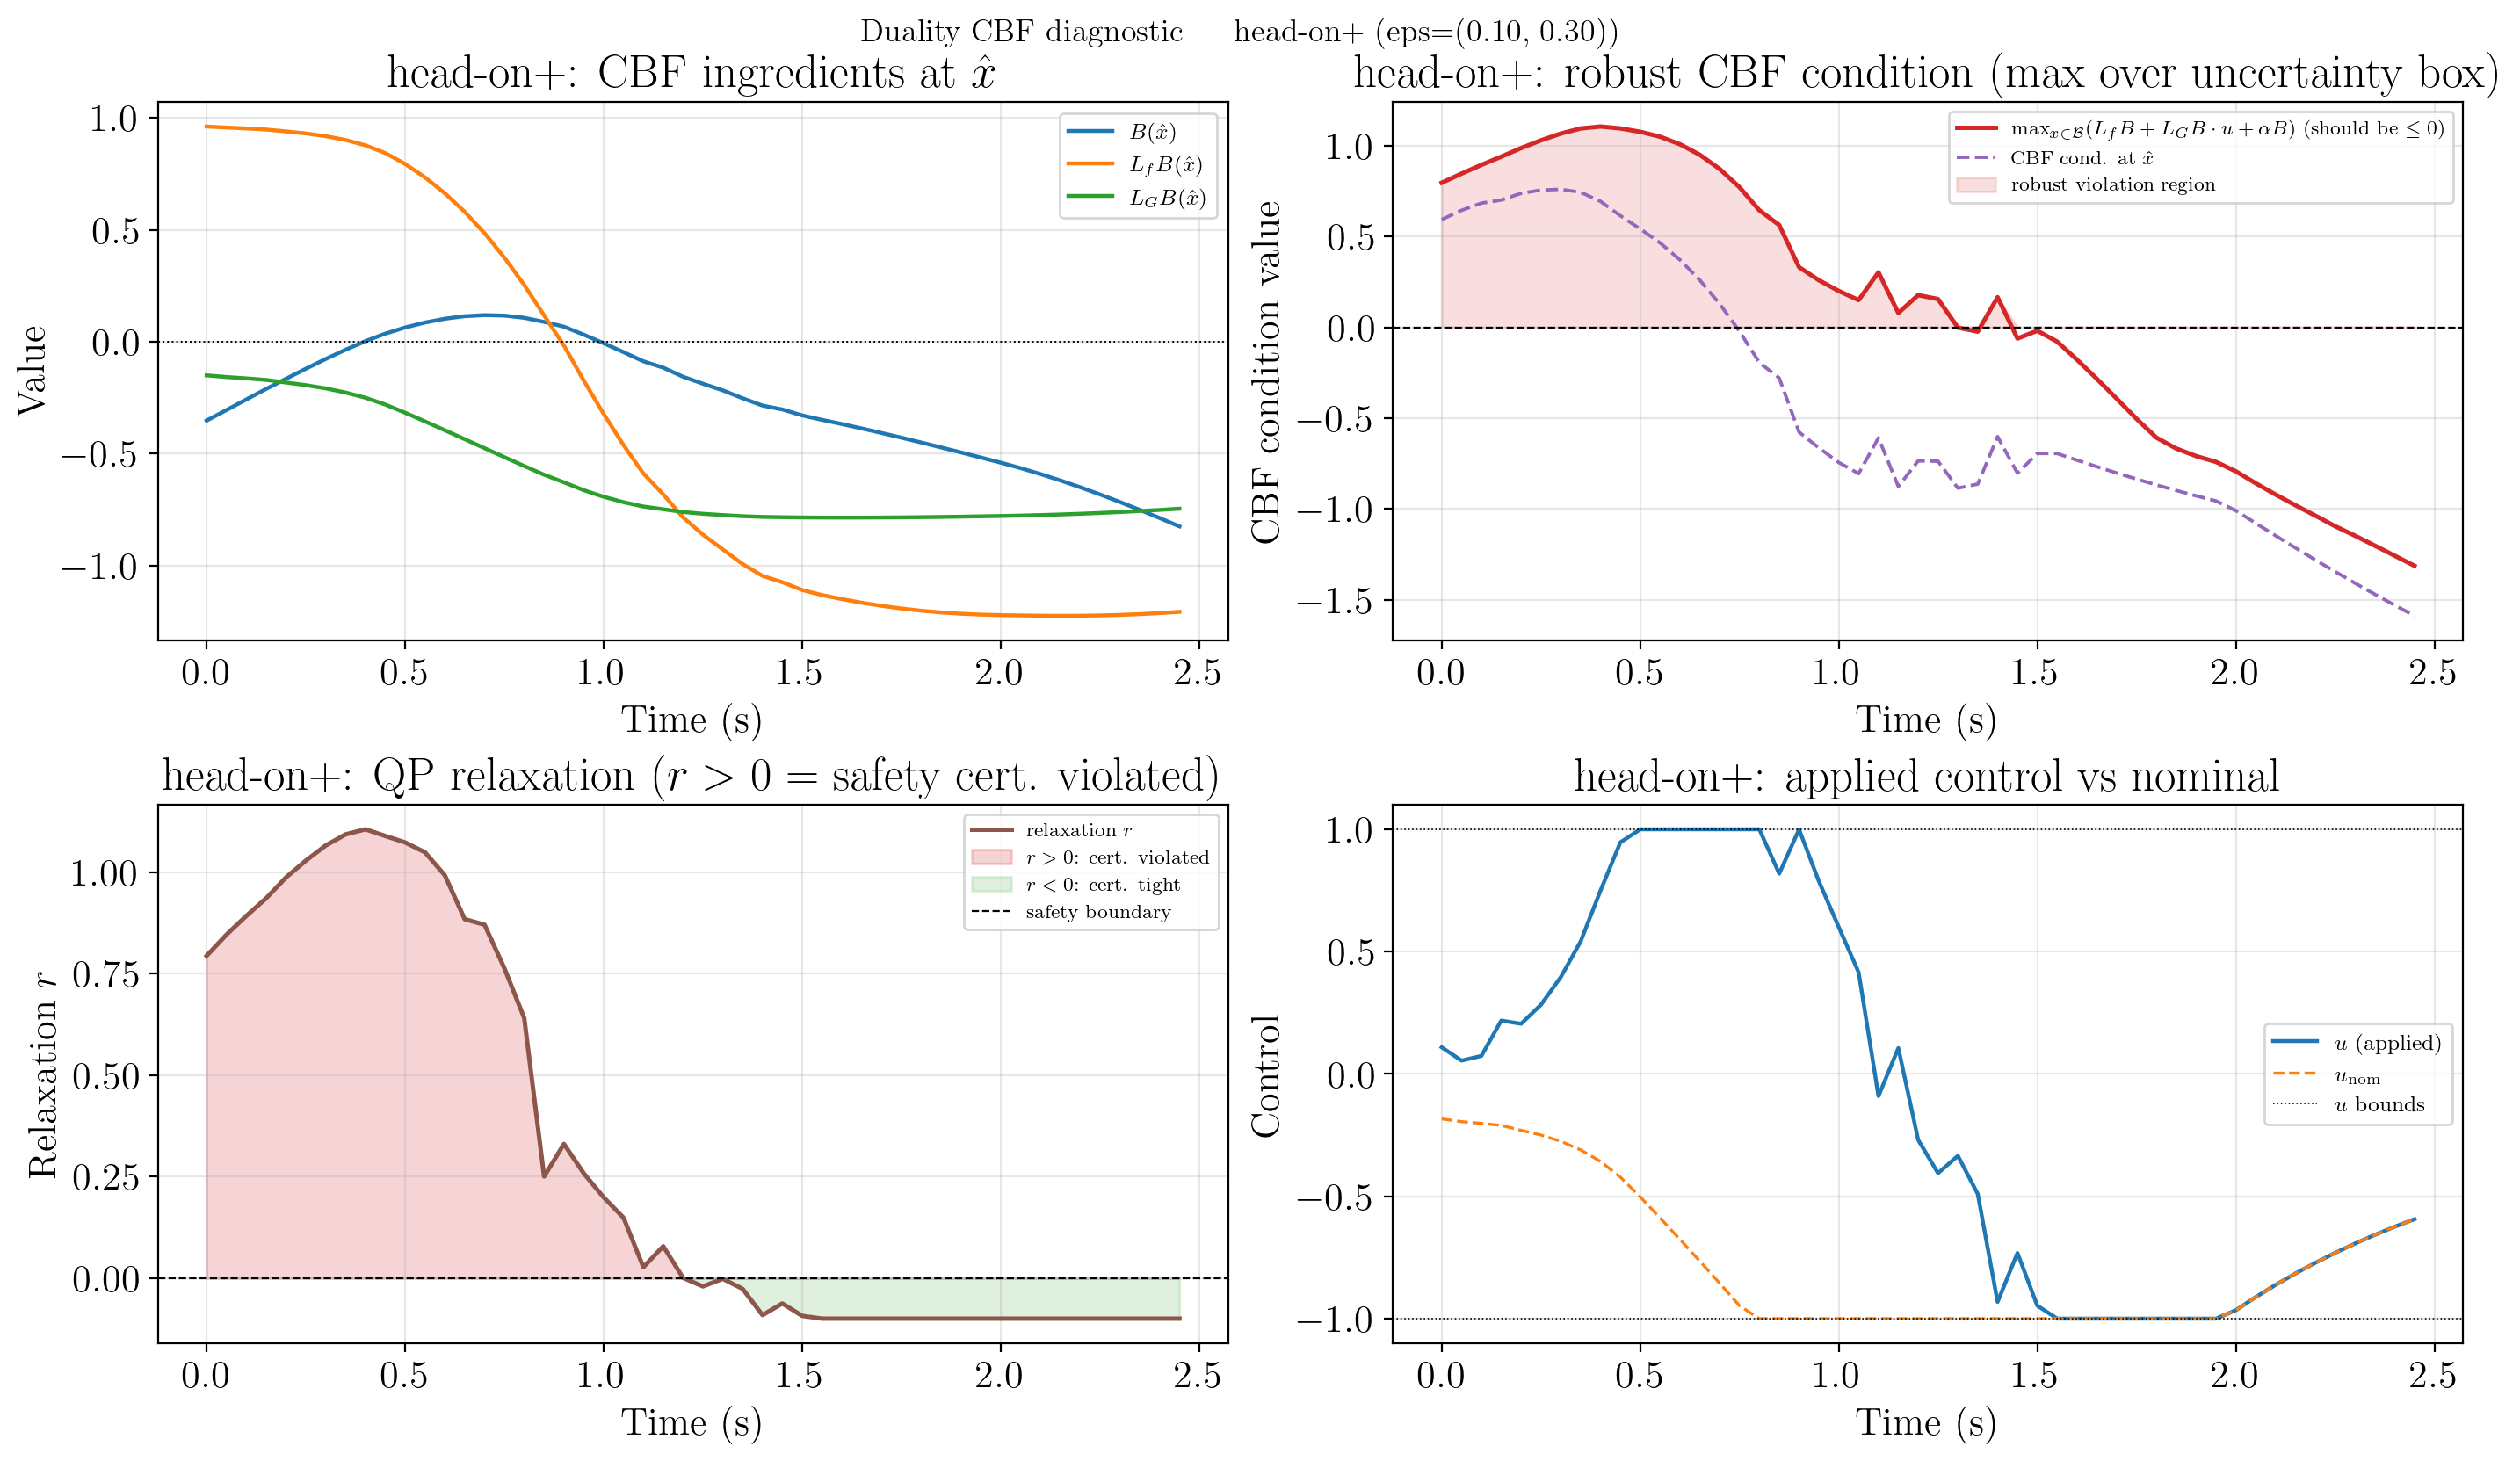

head-on+ (50 steps):
  r > 0 (cert. violated):         25/50  (50%)
  max CBF cond > 0 (robust viol): 27/50  (54%)
  max r:    1.1052
  max cbf_wc: 1.1054



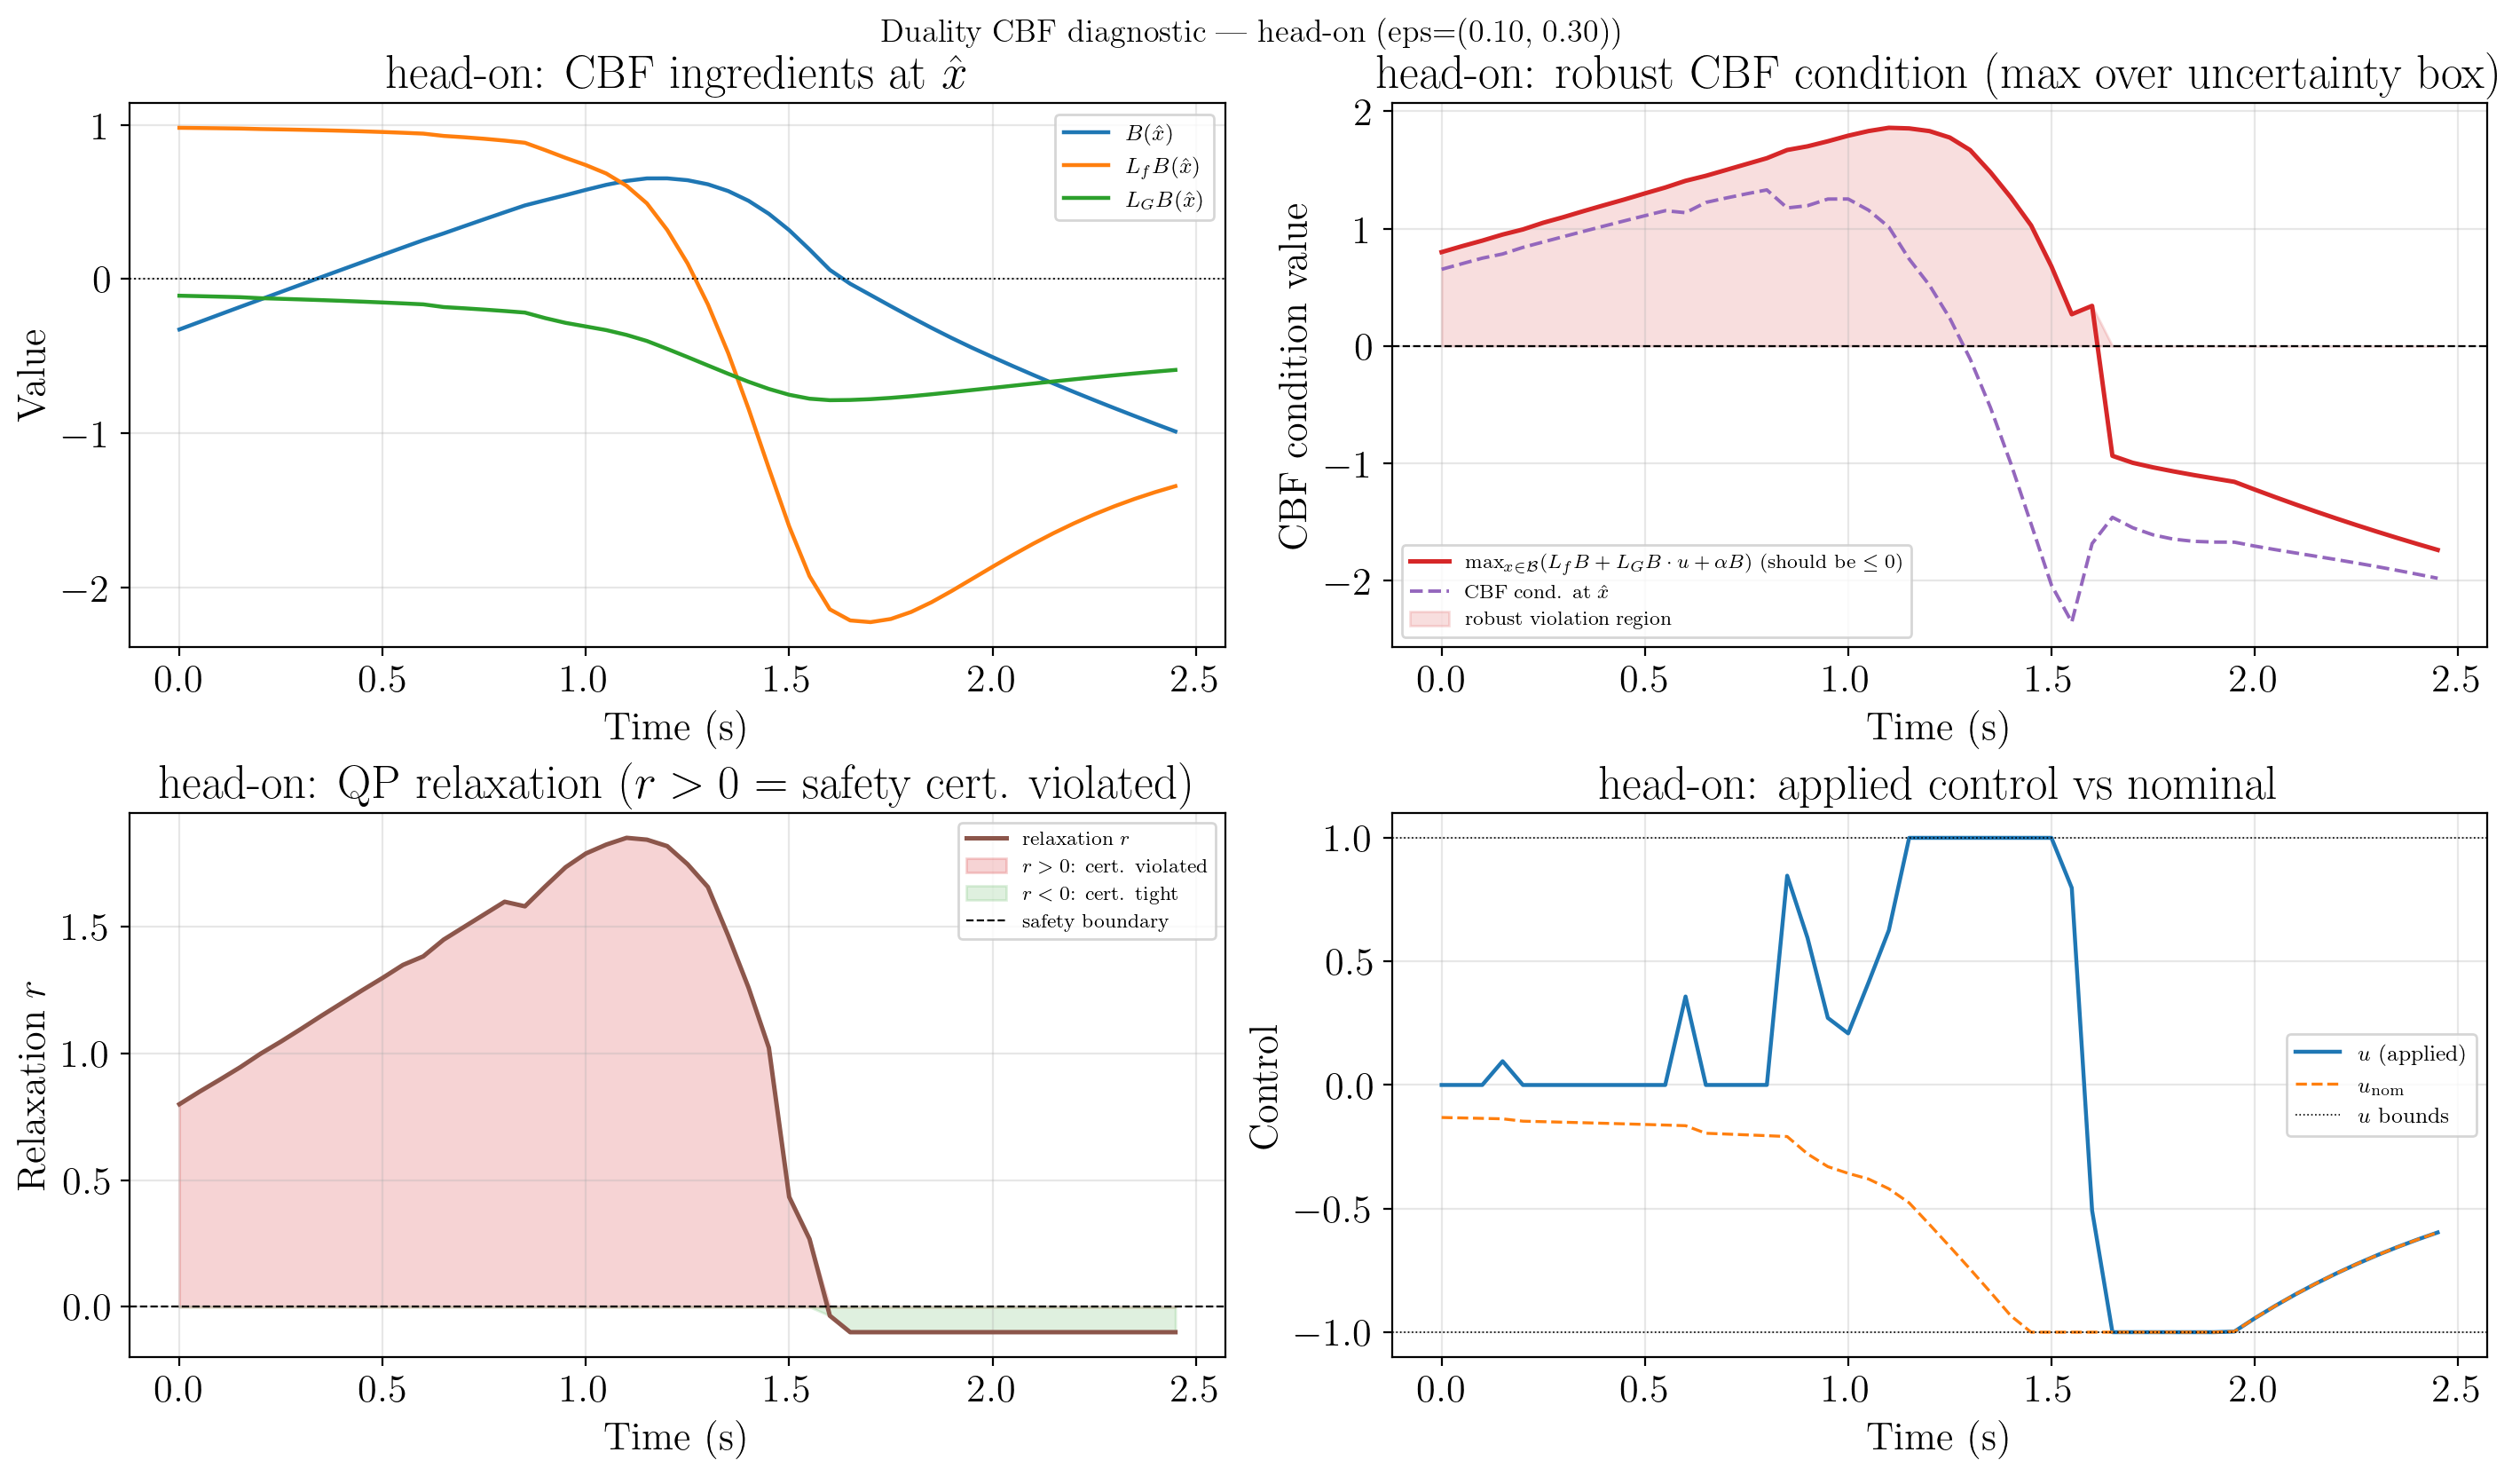

head-on (50 steps):
  r > 0 (cert. violated):         32/50  (64%)
  max CBF cond > 0 (robust viol): 33/50  (66%)
  max r:    1.8513
  max cbf_wc: 1.8587



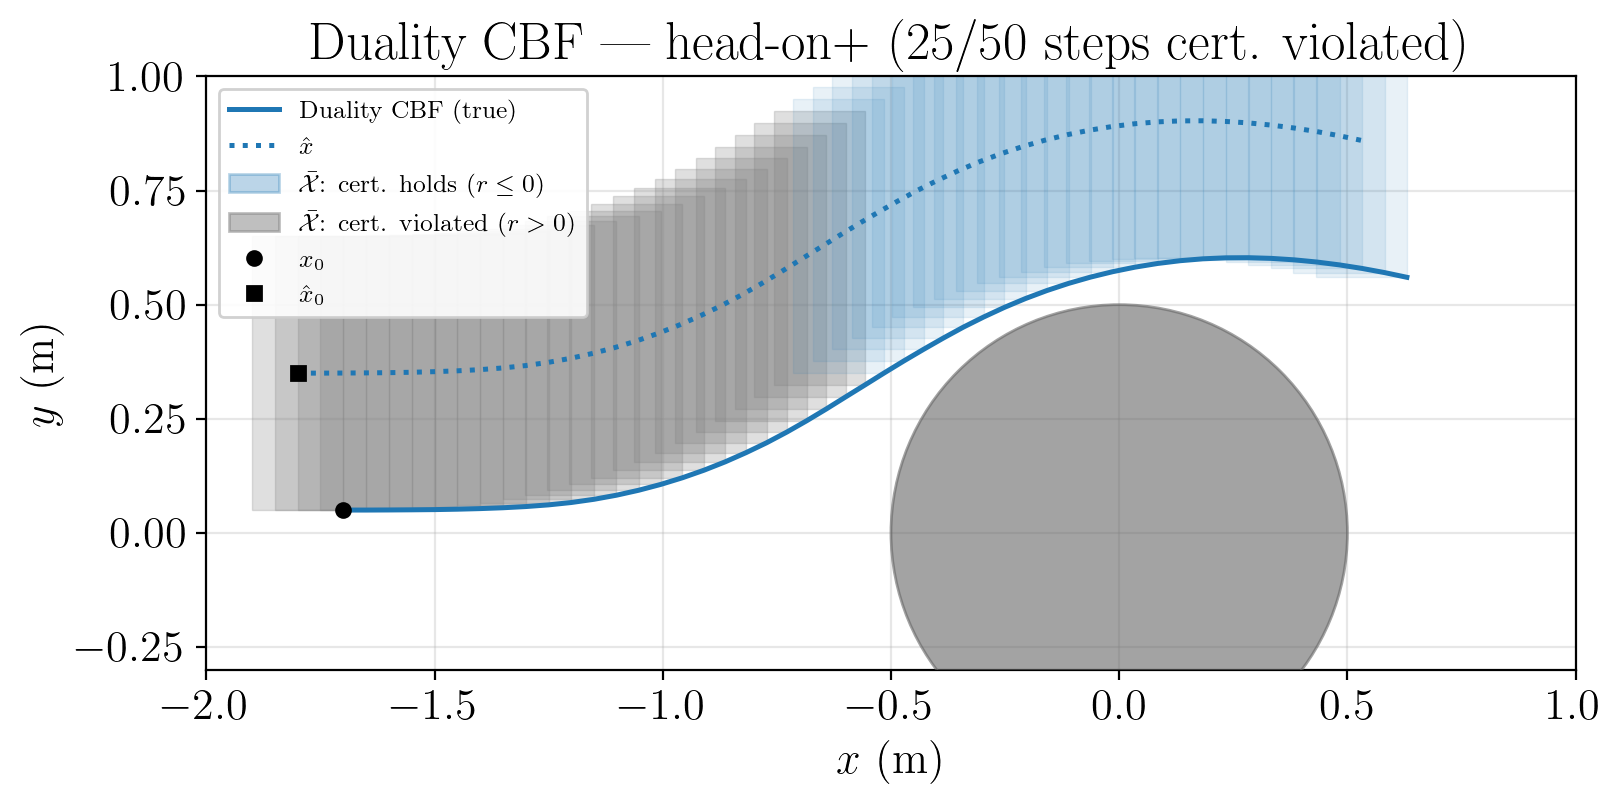

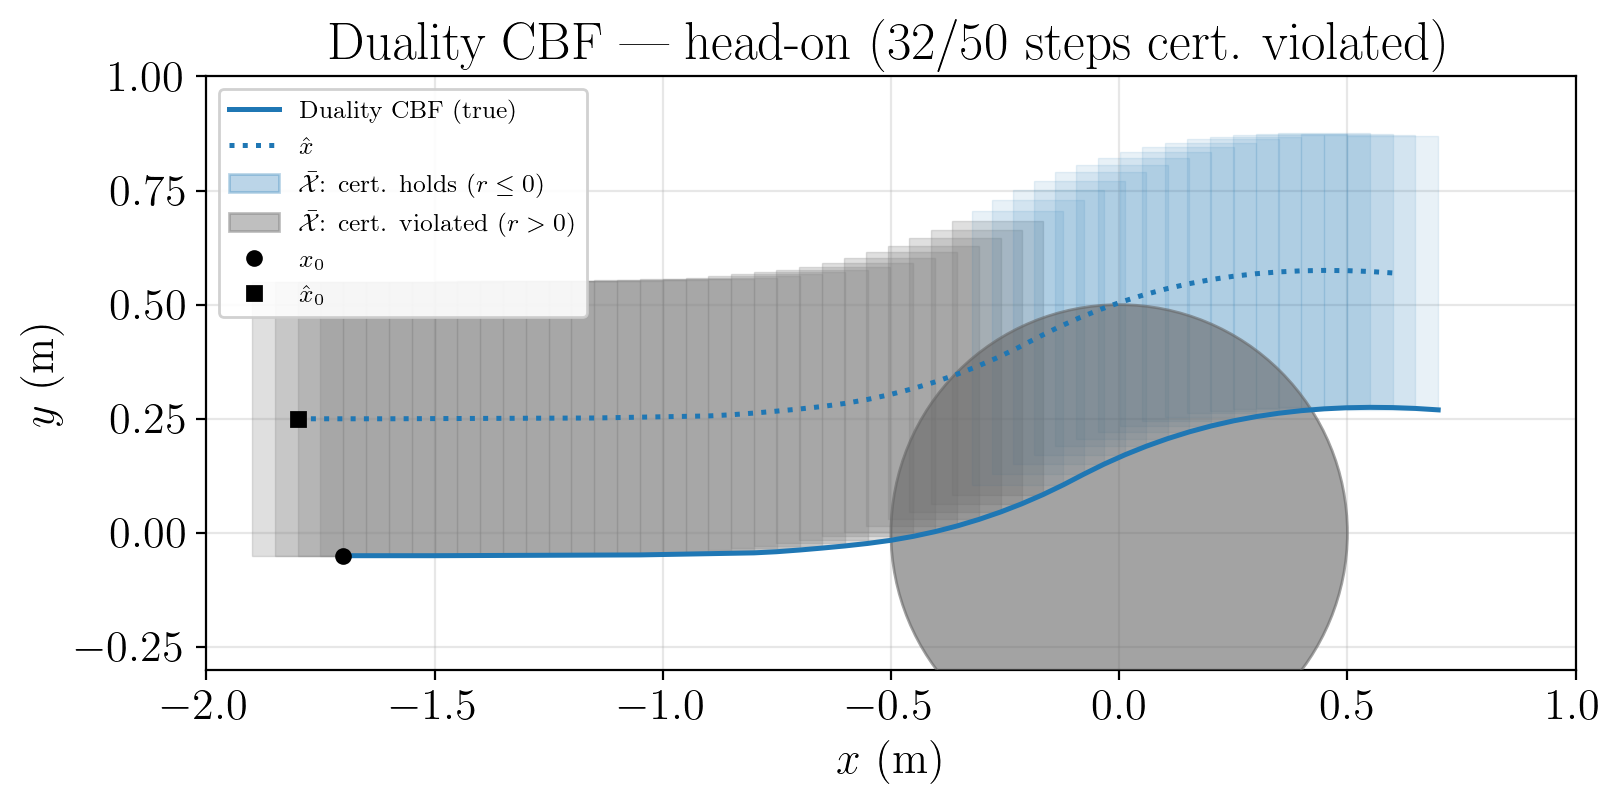

In [213]:
# ── Duality CBF diagnostic (correct formulation) ──────────────────────────────
# For each IC, run the corrected duality step and record:
#   - Polytope support values d_poly (how tight the image-set approximation is)
#   - Relaxation variable r (r > 0 means the safety certificate is violated)
#   - Max CBF condition over the uncertainty box with the applied u
#   - Applied u vs u_nom

@jax.jit
def _duality_step_diag(carry, step_idx):
    """Correct duality CBF diagnostic — mirrors _duality_step exactly but records internals."""
    x, bias = carry
    xhat  = x + bias
    lo    = xhat - STATE_EPS_DUAL
    hi    = xhat + STATE_EPS_DUAL
    u_nom = task.nom_pol_goto(xhat)

    opt_key  = jax.random.fold_in(BASE_KEY, step_idx)
    all_keys = jax.random.split(opt_key, N_PLANES_DUAL)

    def _support_one(d_vec, k_j):
        def _obj(xi):
            return d_vec @ _image_fn(xi)
        val, _ = proj_grad_max_box(_obj, lo, hi, n_restarts=2, n_steps=15, lr=0.05, key=k_j)
        return val

    d_poly = jax.vmap(_support_one)(_DUAL_DIRS, all_keys)   # (N,)

    u_opt, r_opt, _ = _duality_cbf_qp(
        _DUAL_DIRS, d_poly, u_nom[0], _u_lb_scalar, _u_ub_scalar,
        penalty=10.0, relax_eps=0.1
    )
    u = jnp.array([u_opt])

    # CBF ingredients at the estimated state
    h_nom, Lf_nom, LG_nom = _cbf_ingredients(xhat)
    cbf_at_xhat = Lf_nom[0] + LG_nom[0, 0] * u[0] + ALPHA_QP * h_nom[0]

    # True worst-case CBF condition with the applied u — max over uncertainty box
    wc_key = jax.random.fold_in(BASE_KEY, step_idx + 99999)
    def _cbf_cond_obj(xi):
        h, Lf_h, LG_h = _cbf_ingredients(xi)
        return Lf_h[0] + LG_h[0, 0] * u[0] + ALPHA_QP * h[0]
    cbf_max_wc, _ = proj_grad_max_box(_cbf_cond_obj, lo, hi,
                                       n_restarts=2, n_steps=15, lr=0.05, key=wc_key)

    x_next = x + DT * task.xdot(x, u)
    diag = {
        'x_true':      x,
        'xhat':        xhat,
        'u_nom':       u_nom,
        'u_applied':   u,
        'r_relax':     r_opt,          # relaxation: r > 0 means cert. violated
        'd_poly':      d_poly,         # (N,) support values
        'h_nom':       h_nom[0],       # B(xhat)
        'Lf_nom':      Lf_nom[0],
        'LG_nom':      LG_nom[0, 0],
        'cbf_at_xhat': cbf_at_xhat,   # CBF cond at xhat with applied u
        'cbf_max_wc':  cbf_max_wc,    # max CBF cond over box with applied u (>0 = unsafe)
    }
    return (x_next, bias), diag

def _run_duality_diag(x0, bias):
    _, diag = jax.lax.scan(_duality_step_diag, (x0, bias), jnp.arange(T))
    return diag

_run_duality_diag_jit = jax.jit(_run_duality_diag)
print("Compiling duality diagnostic...")
_ = _run_duality_diag_jit(jnp.array(list(x_ics.values())[0]),
                           jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], 0.0]))
print("  done")

# ── Plot diagnostic for each IC ───────────────────────────────────────────────
for ic_name in ['head-on+', 'head-on']:
    x0   = x_ics[ic_name]
    bias = jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], STATE_EPS_DUAL[2] * 0.0])
    diag = jax2np(_run_duality_diag_jit(jnp.array(x0), bias))

    t_arr    = np.arange(T) * DT
    u_lb_val = float(u_lb[0])
    u_ub_val = float(u_ub[0])

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), layout='constrained')

    # --- Panel (0,0): barrier value and CBF condition over time ---
    ax = axes[0, 0]
    ax.plot(t_arr, diag['h_nom'],       '-',  color='C0', lw=1.6, label=r'$B(\hat{x})$')
    ax.plot(t_arr, diag['Lf_nom'],      '-',  color='C1', lw=1.6, label=r'$L_f B(\hat{x})$')
    ax.plot(t_arr, diag['LG_nom'],      '-',  color='C2', lw=1.6, label=r'$L_G B(\hat{x})$')
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set(xlabel='Time (s)', ylabel='Value',
           title=f'{ic_name}: CBF ingredients at $\\hat{{x}}$')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)

    # --- Panel (0,1): robust CBF condition (max over box) with applied u ---
    ax = axes[0, 1]
    ax.plot(t_arr, diag['cbf_max_wc'],  '-',  color='C3', lw=1.8,
            label=r'$\max_{x\in\mathcal{B}} (L_fB + L_GB\cdot u + \alpha B)$  (should be $\leq 0$)')
    ax.plot(t_arr, diag['cbf_at_xhat'], '--', color='C4', lw=1.4,
            label=r'CBF cond. at $\hat{x}$')
    ax.fill_between(t_arr, 0, np.maximum(diag['cbf_max_wc'], 0),
                    color='C3', alpha=0.15, label='robust violation region')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set(xlabel='Time (s)', ylabel='CBF condition value',
           title=f'{ic_name}: robust CBF condition (max over uncertainty box)')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

    # --- Panel (1,0): relaxation r over time ---
    ax = axes[1, 0]
    r_vals = diag['r_relax']
    ax.plot(t_arr, r_vals, '-', color='C5', lw=1.8, label='relaxation $r$')
    ax.fill_between(t_arr, 0, np.maximum(r_vals, 0),
                    color='C3', alpha=0.2, label='$r > 0$: cert. violated')
    ax.fill_between(t_arr, np.minimum(r_vals, 0), 0,
                    color='C2', alpha=0.15, label='$r < 0$: cert. tight')
    ax.axhline(0, color='k', lw=0.8, ls='--', label='safety boundary')
    ax.set(xlabel='Time (s)', ylabel='Relaxation $r$',
           title=f'{ic_name}: QP relaxation ($r>0$ = safety cert. violated)')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

    # --- Panel (1,1): applied u vs u_nom ---
    ax = axes[1, 1]
    ax.plot(t_arr, diag['u_applied'][:, 0], '-',  color='C0', lw=1.6, label=r'$u$ (applied)')
    ax.plot(t_arr, diag['u_nom'][:, 0],     '--', color='C1', lw=1.2, label=r'$u_{\mathrm{nom}}$')
    ax.axhline(u_lb_val, color='k', ls=':', lw=0.6, label='$u$ bounds')
    ax.axhline(u_ub_val, color='k', ls=':', lw=0.6)
    ax.set(xlabel='Time (s)', ylabel='Control',
           title=f'{ic_name}: applied control vs nominal')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)

    n_relax    = (r_vals > 0).sum()
    n_wc_viol  = (diag['cbf_max_wc'] > 0).sum()
    fig.suptitle(
        f'Duality CBF diagnostic — {ic_name}  '
        f'(eps=({float(STATE_EPS_DUAL[0]):.2f}, {float(STATE_EPS_DUAL[1]):.2f}))',
        fontsize=13, y=1.02
    )
    plt.show()
    print(f"{ic_name} ({T} steps):")
    print(f"  r > 0 (cert. violated):         {n_relax}/{T}  ({100*n_relax/T:.0f}%)")
    print(f"  max CBF cond > 0 (robust viol): {n_wc_viol}/{T}  ({100*n_wc_viol/T:.0f}%)")
    print(f"  max r:    {r_vals.max():.4f}")
    print(f"  max cbf_wc: {diag['cbf_max_wc'].max():.4f}")
    print()


# ── Trajectory with r-coloured uncertainty rectangles ─────────────────────────
for ic_name in ['head-on+', 'head-on']:
    x0   = x_ics[ic_name]
    bias = jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], STATE_EPS_DUAL[2] * 0.0])
    diag = jax2np(_run_duality_diag_jit(jnp.array(x0), bias))

    xs_true = diag['x_true']
    xhats   = diag['xhat']
    r_vals  = diag['r_relax']
    ex = float(STATE_EPS_DUAL[0])
    ey = float(STATE_EPS_DUAL[1])

    fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.4', alpha=0.6, zorder=3)
    ax.add_patch(obs_p)

    # Uncertainty rectangles — grey if r > 0 (cert. violated), blue if r <= 0
    for t in range(T):
        cx, cy = xhats[t, 0], xhats[t, 1]
        violated = r_vals[t] > 0
        rect_color = '0.5' if violated else 'C0'
        rect_alpha = 0.25  if violated else 0.10
        rect = mpatches.Rectangle(
            (cx - ex, cy - ey), 2*ex, 2*ey,
            linewidth=0.5, edgecolor=rect_color, facecolor=rect_color,
            alpha=rect_alpha, zorder=2
        )
        ax.add_patch(rect)

    ax.plot(xs_true[:, 0], xs_true[:, 1], '-',  color='C0', lw=1.8, label='Duality CBF (true)', zorder=4)
    ax.plot(xhats[:, 0],   xhats[:, 1],   ':',  color='C0', lw=1.8, label=r'$\hat{x}$', zorder=4)
    ax.plot(xs_true[0, 0], xs_true[0, 1], 'ko', ms=5, zorder=6, label=r'$x_0$ (true)')
    ax.plot(xhats[0, 0],   xhats[0, 1],   'ks', ms=5, zorder=6, label=r'$\hat{x}_0$')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        plt.Line2D([], [], color='C0', lw=1.8,  label='Duality CBF (true)'),
        plt.Line2D([], [], color='C0', lw=1.8, ls=':', label=r'$\hat{x}$'),
        Patch(facecolor='C0', edgecolor='C0', alpha=0.3, label=r'$\bar{\mathcal{X}}$: cert. holds ($r\leq0$)'),
        Patch(facecolor='0.5', edgecolor='0.5', alpha=0.5, label=r'$\bar{\mathcal{X}}$: cert. violated ($r>0$)'),
        plt.Line2D([], [], marker='o', color='k', ls='', ms=5, label=r'$x_0$'),
        plt.Line2D([], [], marker='s', color='k', ls='', ms=5, label=r'$\hat{x}_0$'),
    ], fontsize=9, loc='upper left', framealpha=0.9)

    n_viol = (r_vals > 0).sum()
    ax.set(xlim=(-2.0, 1.0), ylim=(-0.3, 1.0), aspect='equal',
           xlabel='$x$ (m)', ylabel='$y$ (m)',
           title=f'Duality CBF — {ic_name}  ({n_viol}/{T} steps cert. violated)')
    ax.grid(alpha=0.3)
    plt.show()


## Monte Carlo safety evaluation (N = 1000)

Sample initial conditions uniformly from a region approaching the obstacle, filter to those inside the CBF-invariant set (`handcbf_B(x0) < 0`), and check **true** safety (`h_components > 0` at any timestep = collision).

In [9]:
# ── Cache check: skip rollouts if results already saved for this eps_y ──────
import pickle
from pathlib import Path

# _mc_results_dir = Path('../../runs/nmr_cbf_dubins3d/mc_sweep/8_planes')
eps_y_val = float(STATE_EPS_DUAL[1])
_mc_file = _mc_results_dir / f'mc_eps_y_{eps_y_val:.4f}.pkl'

_loaded_from_cache = False
if _mc_file.exists():
    with open(_mc_file, 'rb') as _f:
        _cached = pickle.load(_f)
    if 'violation_array' in _cached and 'px_mc' in _cached:
        print(f"Loading cached MC results from {_mc_file}")
        mc_results = {name: np.array(arr, dtype=bool)
                      for name, arr in _cached['violation_array'].items()}
        px_mc  = np.array(_cached['px_mc'])
        py_mc  = np.array(_cached['py_mc'])
        N_MC   = _cached['N_MC']
        mc_trajs   = None   # full trajectories not cached; effort cell will warn
        mc_biases  = None
        x0s_mc     = None
        _loaded_from_cache = True
        print(f"  Loaded {N_MC} ICs, {len(mc_results)} policies.")
        for name, viol in mc_results.items():
            print(f"  {name:<14}  {viol.sum():5}/{N_MC}  {100*viol.mean():.1f}%")
    else:
        print(f"Cache file exists but missing violation_array — will re-run.")

if not _loaded_from_cache:
    # ── Sample candidates ─────────────────────────────────────────────────────────
    N_MC   = 50_000
    # N_MC   = 1_000
    N_CAND = 1_500_000
    rng_mc = np.random.default_rng(42)
    
    # Approach from the left half-plane with varied heading
    px_cand    = rng_mc.uniform(-2.0, -0.5, N_CAND)
    py_cand    = rng_mc.uniform(-0.6, 0.6, N_CAND)
    theta_cand = rng_mc.uniform(-np.pi/600, np.pi/600, N_CAND)
    
    x0s_cand = jnp.array(np.stack([px_cand, py_cand, theta_cand], axis=1), dtype=jnp.float32)
    
    # ── Filter: (1) outside obstacle  AND  (2) inside CBF-invariant set ──────────
    h0_cand = jax2np(jax.vmap(task.h_components)(x0s_cand))
    B0_cand = jax2np(jax.vmap(task.handcbf_B, in_axes=(0, None))(x0s_cand, hocbf_alpha))
    
    outside_obs = h0_cand.max(axis=1) < 0
    in_cbf_set  = B0_cand.max(axis=1) < 0
    safe_mask   = outside_obs & in_cbf_set
    
    n_safe = safe_mask.sum()
    print(f"Candidates: {N_CAND}")
    print(f"  outside obstacle:       {outside_obs.sum():5}  ({100*outside_obs.mean():.1f}%)")
    print(f"  inside CBF set (psi<0): {in_cbf_set.sum():5}  ({100*in_cbf_set.mean():.1f}%)")
    print(f"  both (usable):          {n_safe:5}  ({100*n_safe/N_CAND:.1f}%)")
    assert n_safe >= N_MC, f"Too few safe ICs ({n_safe}); increase N_CAND."
    
    safe_idx = np.where(safe_mask)[0][:N_MC]
    x0s_mc   = x0s_cand[safe_idx]
    px_mc    = px_cand[safe_idx]
    py_mc    = py_cand[safe_idx]
    print(f"Using {N_MC} ICs: outside obstacle AND handcbf_B < 0")
    
    # ── Sample one independent bias per trajectory ────────────────────────────────
    bias_keys = jax.random.split(jax.random.PRNGKey(99), N_MC)
    mc_biases = jax.vmap(_sample_bias)(bias_keys)   # (N_MC, nx)
    print(f"Bias stats: mean={float(jnp.abs(mc_biases).mean()):.3f} m,  "
          f"max={float(jnp.abs(mc_biases).max()):.3f} m")
    
    # ── Run MC rollouts ───────────────────────────────────────────────────────────
    mc_rollout_nom     = jax.jit(jax.vmap(rollout_nom_noisy))
    mc_rollout_cbf     = jax.jit(jax.vmap(rollout_cbf_noisy))
    mc_rollout_rcbf    = jax.jit(jax.vmap(rollout_rcbf))
    mc_rollout_duality = jax.jit(jax.vmap(rollout_duality))
    mc_rollout_rcbf_02 = jax.jit(jax.vmap(rollout_rcbf_02))
    mc_rollout_rcbf_10 = jax.jit(jax.vmap(rollout_rcbf_10))
    # MR-CBF uses cvxpy (Python loop), so batch manually
    MC_MRCBF_BATCH = 50
    def mc_rollout_mrcbf(x0s, biases):
        xs_chunks, xh_chunks = [], []
        for i in range(x0s.shape[0]):
            xs_c, xh_c = _mrcbf_rollout(x0s[i], biases[i])
            xs_chunks.append(xs_c)
            xh_chunks.append(xh_c)
            if i % 500 == 0:
                print(f'    MR-CBF {i}/{x0s.shape[0]}...')
        return jnp.stack(xs_chunks), jnp.stack(xh_chunks)
    mc_rollout_nmr     = jax.jit(jax.vmap(rollout_nmr_cbf))
    # GUARDIAN is too memory-heavy to vmap over all N_MC at once
    # (each step evaluates num_controls x num_states x num_disturbances).
    # Batch in chunks instead.
    MC_GUARDIAN_BATCH = 1000
    _guardian_vmap = jax.jit(jax.vmap(rollout_guardian))
    def mc_rollout_guardian(x0s, biases):
        xs_chunks, xh_chunks = [], []
        for i in range(0, x0s.shape[0], MC_GUARDIAN_BATCH):
            xs_c, xh_c = _guardian_vmap(x0s[i:i+MC_GUARDIAN_BATCH],
                                         biases[i:i+MC_GUARDIAN_BATCH])
            xs_chunks.append(xs_c)
            xh_chunks.append(xh_c)
            if (i // MC_GUARDIAN_BATCH) % 10 == 0:
                print(f'    GUARDIAN batch {i//MC_GUARDIAN_BATCH}/{x0s.shape[0]//MC_GUARDIAN_BATCH}...')
        return jnp.concatenate(xs_chunks), jnp.concatenate(xh_chunks)
    # mc_rollout_nmr_rcbf = jax.jit(jax.vmap(rollout_nmr_rcbf))
    
    print("Compiling + running Monte Carlo rollouts...")
    mc_trajs = {}
    for pol_name, mc_fn in [('Nom+noise',   mc_rollout_nom),
                             ('CBF+noise',   mc_rollout_cbf),
                             ('R-CBF-QP',    mc_rollout_rcbf),
                             ('Duality CBF', mc_rollout_duality),
                             ('R-CBF (0.2)', mc_rollout_rcbf_02),
                             ('R-CBF (1.0)', mc_rollout_rcbf_10),
                            #  ('MR-CBF',      mc_rollout_mrcbf),
                             ('NMR-CBF',     mc_rollout_nmr),
                             ('GUARDIAN',     mc_rollout_guardian),
                            #  ('NMR+RCBF',    mc_rollout_nmr_rcbf)
                             ]:
        xs_all, _ = jax2np(mc_fn(x0s_mc, mc_biases))   # (N_MC, T+1, nx)
        mc_trajs[pol_name] = xs_all
        print(f"  {pol_name} done.")
    
    # ── True safety check ─────────────────────────────────────────────────────────
    print("Evaluating safety...")
    h_vmap_mc = jax.jit(jax.vmap(jax.vmap(task.h_components)))
    
    mc_results = {}
    for pol_name, xs_all in mc_trajs.items():
        h_all    = jax2np(h_vmap_mc(jnp.array(xs_all)))
        violated = h_all.max(axis=(1, 2)) > 0
        mc_results[pol_name] = violated
        n_viol = violated.sum()
        rate   = n_viol / N_MC
        z      = 1.96
        lo_ci = (rate + z**2/(2*N_MC) - z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
        hi_ci = (rate + z**2/(2*N_MC) + z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
        print(f"  {pol_name:<14}  {n_viol:4}/{N_MC}  {100*rate:5.1f}%  "
              f"95% CI [{100*lo_ci:.1f}%, {100*hi_ci:.1f}%]")
    
    # ── Plots ─────────────────────────────────────────────────────────────────────
    pol_names  = list(mc_results.keys())
    pol_colors = ['C3', 'C1', 'C4', 'C0', 'C6', 'C7', 'C8', 'C2', 'C5', 'C9']
    rates = [mc_results[n].mean() for n in pol_names]
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout='constrained')
    
    axes[0].bar(pol_names, [100*r for r in rates], color=pol_colors, width=0.5, zorder=3)
    axes[0].set(ylabel='Violation rate (\\%)',
                title=f'True collisions (N={N_MC}, outside obs \& in CBF set)')
    axes[0].set_ylim(0, max(100*max(rates)*1.3, 3))
    axes[0].grid(axis='y', alpha=0.4, zorder=0)
    for i, r in enumerate(rates):
        axes[0].text(i, 100*r + 0.15, f'{100*r:.1f}%', ha='center', va='bottom', fontsize=9)
    
    viol_dual = mc_results['Duality CBF'].astype(float)
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.4', alpha=0.7, zorder=4)
    axes[1].add_patch(obs_p)
    sc = axes[1].scatter(px_mc, py_mc, c=viol_dual, cmap='RdYlGn_r', vmin=0, vmax=1,
                         s=8, alpha=0.6, zorder=3)
    plt.colorbar(sc, ax=axes[1], label='violated (1=yes)')
    axes[1].set(xlabel='x0 (m)', ylabel='y0 (m)', aspect='equal',
                xlim=(-2.5, 0.5), ylim=(-2.0, 2.0),
                title='Duality CBF violations by IC position')
    axes[1].grid(alpha=0.3)
    
    dist_mc = np.sqrt(px_mc**2 + py_mc**2)
    bins = np.linspace(dist_mc.min(), dist_mc.max(), 10)
    bin_centers = 0.5*(bins[:-1] + bins[1:])
    bin_idx_arr = np.digitize(dist_mc, bins) - 1
    for pol_name, col in zip(pol_names, pol_colors):
        viol = mc_results[pol_name].astype(float)
        bin_rate = [viol[bin_idx_arr == b].mean() if (bin_idx_arr == b).any() else np.nan
                    for b in range(len(bins)-1)]
        axes[2].plot(bin_centers, [100*r for r in bin_rate],
                     color=col, marker='o', ms=4, lw=1.5, label=pol_name)
    axes[2].set(xlabel='Initial distance to obstacle (m)', ylabel='Violation rate (\\%)',
                title='Violations vs initial distance')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)
    axes[2].set_ylim(bottom=0)
    
    fig.suptitle(f'Monte Carlo (N={N_MC}) — constant bias eps={float(STATE_EPS_DUAL[0]):.2f} m, '
                 f'hocbf_alpha={hocbf_alpha}, ALPHA_QP={ALPHA_QP}')
    plt.show()
    

Candidates: 1500000
  outside obstacle:       1500000  (100.0%)
  inside CBF set (psi<0): 572356  (38.2%)
  both (usable):          572356  (38.2%)
Using 50000 ICs: outside obstacle AND handcbf_B < 0
Bias stats: mean=0.050 m,  max=0.150 m


NameError: name 'rollout_nmr_cbf' is not defined

In [215]:
# ── Head-on filter: xhat_y0 in [-0.01, 0.01] ─────────────────────────────────
# Regenerate biases from the same seed used in the MC cell (no re-simulation needed).
# mc_biases is None when loaded from cache, so we reconstruct it deterministically.
if mc_biases is None:
    _bias_keys = jax.random.split(jax.random.PRNGKey(99), N_MC)
    _mc_biases_r = jax2np(jax.vmap(_sample_bias)(_bias_keys))   # (N_MC, nx)
else:
    _mc_biases_r = jax2np(mc_biases)

# xhat at t=0: true IC + bias
xhat_y0 = py_mc + _mc_biases_r[:, 1]   # y-component of initial measurement

HEADON_EPS = 0.02
headon_mask = np.abs(xhat_y0) >= HEADON_EPS
N_headon = headon_mask.sum()
print(f"Head-on filter: |xhat_y0| >= {HEADON_EPS} m")
print(f"  {N_headon} / {N_MC} ICs pass ({100*N_headon/N_MC:.1f}%)")
print(f"  true py range:  [{py_mc[headon_mask].min():.3f}, {py_mc[headon_mask].max():.3f}]")
print(f"  xhat_y0 range:  [{xhat_y0[headon_mask].min():.4f}, {xhat_y0[headon_mask].max():.4f}]")
print()

z = 1.96
for pol_name, viol_all in mc_results.items():
    viol = viol_all[headon_mask]
    n    = len(viol)
    rate = viol.mean()
    lo = (rate + z**2/(2*n) - z*np.sqrt(rate*(1-rate)/n + z**2/(4*n**2))) / (1 + z**2/n)
    hi = (rate + z**2/(2*n) + z*np.sqrt(rate*(1-rate)/n + z**2/(4*n**2))) / (1 + z**2/n)
    print(f"  {pol_name:<14}  {viol.sum():5}/{n}  {100*rate:5.1f}%  "
          f"95% CI [{100*lo:.1f}%, {100*hi:.1f}%]")


Head-on filter: |xhat_y0| >= 0.02 m
  48518 / 50000 ICs pass (97.0%)
  true py range:  [-0.600, 0.600]
  xhat_y0 range:  [-0.8883, 0.8956]

  Nom+noise       48466/48518   99.9%  95% CI [99.9%, 99.9%]
  CBF+noise        5127/48518   10.6%  95% CI [10.3%, 10.8%]
  R-CBF-QP          249/48518    0.5%  95% CI [0.5%, 0.6%]
  Duality CBF     20332/48518   41.9%  95% CI [41.5%, 42.3%]
  R-CBF (0.2)      3057/48518    6.3%  95% CI [6.1%, 6.5%]
  R-CBF (1.0)       345/48518    0.7%  95% CI [0.6%, 0.8%]
  NMR-CBF           362/48518    0.7%  95% CI [0.7%, 0.8%]
  GUARDIAN        24901/48518   51.3%  95% CI [50.9%, 51.8%]


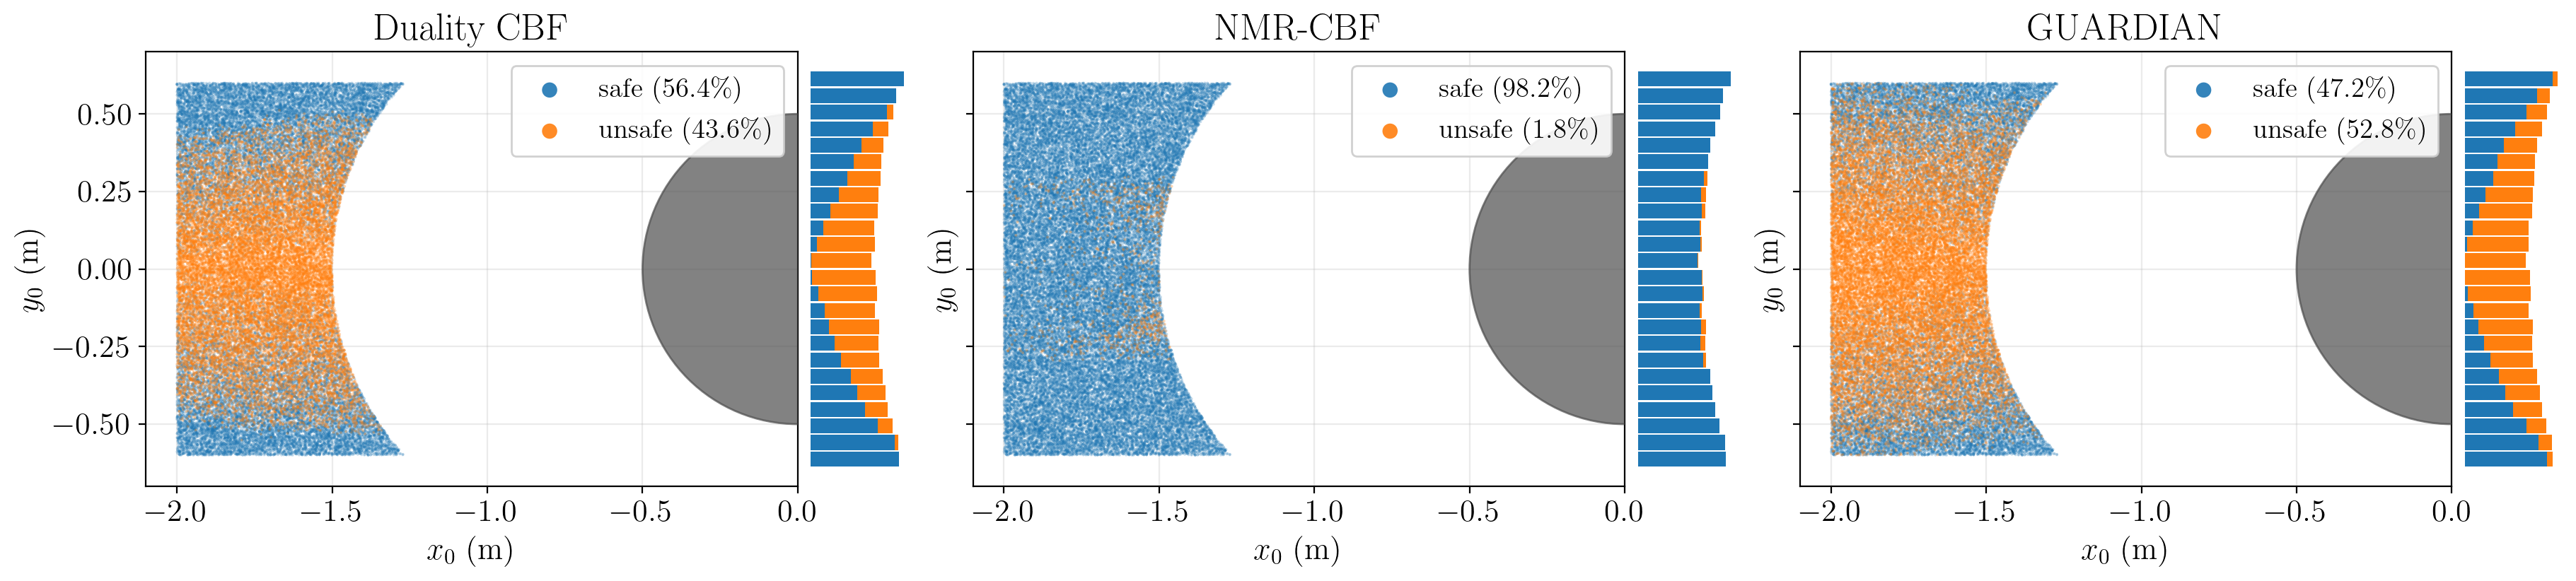

: 

In [ ]:
# ── Violation IC distribution: Duality CBF vs NMR-CBF ────────────────────────
# focus_pols = ['Duality CBF', 'NMR-CBF', 'NMR+RCBF']
focus_pols = ['Duality CBF', 'NMR-CBF', 'GUARDIAN']
# focus_pols = ['GUARDIAN']
focus_cols = ['C0', 'C2', 'C5']

fig, axes = plt.subplots(1, len(focus_pols), figsize=(6*len(focus_pols), 6), layout='constrained',
                         sharex=True, sharey=True)

for ax, pol_name, col in zip(axes, focus_pols, focus_cols):
    viol = mc_results[pol_name]          # (N_MC,) bool
    n_viol = viol.sum()
    rate   = viol.mean()
    # Safe ICs (blue) — plot first so violations sit on top
    safe_col = 'C0'   # tab10 blue
    viol_col = 'C1'   # tab10 orange

    ax.scatter(px_mc[~viol], py_mc[~viol],
               c=safe_col, edgecolors='none', s=2, alpha=0.25,
               zorder=2, label=f'safe ({100*(1-rate):.1f}\\%)')
    # Violating ICs (orange)
    if n_viol > 0:
        ax.scatter(px_mc[viol], py_mc[viol],
                   c=viol_col, edgecolors='none', s=2, alpha=0.3,
                   zorder=3, label=f'{{unsafe ({100*rate:.1f}\\%)}}')

    # Obstacle
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.3', alpha=0.7, zorder=4)
    ax.add_patch(obs_p)

    ax.set(xlim=(-2.1, 0.0), ylim=(-0.7, 0.7), aspect='equal',
           xlabel='$x_0$ (m)', ylabel='$y_0$ (m)',
           title=f'{pol_name}'
    )
    leg = ax.legend(fontsize=14, loc='upper right', framealpha=0.9)
    for h in leg.legend_handles:
        h.set_sizes([60])
        h.set_alpha(0.9)
    ax.grid(alpha=0.25)

    # Marginal histograms — stacked so safe/violated bars sit on top of each other
    # ax_top   = ax.inset_axes([0, 1.02, 1, 0.18])
    ax_right = ax.inset_axes([1.02, 0, 0.15, 1])
    bins_x = np.linspace(-2.2, 0.3, 25)
    bins_y = np.linspace(-0.6, 0.6, 25)

    # ax_top.hist([px_mc[~viol], px_mc[viol]], bins=bins_x,
    #             color=[safe_col, viol_col], stacked=True, rwidth=0.9)
    # ax_top.axis('off')

    ax_right.hist([py_mc[~viol], py_mc[viol]], bins=bins_y,
                  color=[safe_col, viol_col], stacked=True,
                  orientation='horizontal', rwidth=0.9)
    ax_right.axis('off')

# fig.suptitle(
#     f'Violating IC distribution (N={N_MC}, constant bias $\\varepsilon$='
#     f'({float(STATE_EPS_DUAL[0]):.2f}, {float(STATE_EPS_DUAL[1]):.2f}) m)',
#     y=0.85
# )
plt.show()


In [198]:
# ── Control effort vs violation rate scatter ──────────────────────────────────
# Back-compute applied control from state trajectories (Euler, u only affects theta):
#   u_actual = (theta_{t+1} - theta_t) / (DT * umax)
# Compare to what the nominal controller wanted: u_nom = nom_pol_goto(xhat)

_nom_vmap = jax.jit(jax.vmap(jax.vmap(task.nom_pol_goto)))

effort_by_pol = {}
for pol_name, xs_all in mc_trajs.items():
    xs_jnp = jnp.array(xs_all)
    # Back-compute actual control from theta differences
    dtheta = xs_jnp[:, 1:, task.THETA] - xs_jnp[:, :-1, task.THETA]
    # Wrap angle differences to [-pi, pi]
    dtheta = (dtheta + jnp.pi) % (2 * jnp.pi) - jnp.pi
    u_actual = dtheta / (DT * task.umax)                    # (N_MC, T)

    # Nominal control at each step's observed state
    xhats = xs_jnp[:, :-1, :] + mc_biases[:, None, :]       # (N_MC, T, nx)
    u_noms = jax2np(_nom_vmap(xhats))[:, :, 0]              # (N_MC, T)
    u_actual_np = jax2np(u_actual)

    print(f"{pol_name}: mean actual control = {np.abs(u_actual_np).mean():.3f}, "
          f"mean nominal control = {np.abs(u_noms).mean():.3f}")

    # Per-trajectory mean squared control difference
    traj_effort = np.nanmean((u_actual_np - u_noms) ** 2, axis=1)   # (N_MC,); nanmean ignores NaN steps from infeasible QPs
    n_nan = np.isnan(u_actual_np).any(axis=1).sum()
    if n_nan > 0:
        print(f"  {pol_name}: {n_nan}/{u_actual_np.shape[0]} trajectories have NaN controls (QP infeasible)")
    effort_by_pol[pol_name] = traj_effort

# ── Scatter: violation rate vs mean control effort ────────────────────────────
pol_names_plot  = list(mc_results.keys())
pol_colors_plot = dict(zip(
    ['Nom+noise', 'CBF+noise', 'R-CBF-QP', 'Duality CBF',
     'R-CBF (0.2)', 'R-CBF (1.0)', 'MR-CBF',
     'NMR-CBF', 'GUARDIAN'],
    ['C3', 'C1', 'C4', 'C0', 'C6', 'C7', 'C8', 'C2', 'C5']
))
pol_markers_plot = {
    'Duality CBF': 's',    # square
    'GUARDIAN':    '^',    # triangle up
    'NMR-CBF':     'D',    # diamond
    'R-CBF-QP':    'P',    # plus (filled)
}

fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')

for pol_name in pol_names_plot:
    if pol_name != 'Nom+noise':
        viol_rate = 100 * mc_results[pol_name].mean()
        mean_effort = effort_by_pol[pol_name].mean()
        col = pol_colors_plot.get(pol_name, 'k')
        marker = pol_markers_plot.get(pol_name, 'o')
        ax.scatter(mean_effort, viol_rate, s=120, c=col, edgecolors='k',
                marker=marker, linewidths=0.6, zorder=5, label=pol_name)

ax.set(xlabel=r'Mean control effort  $\overline{\|u - u_{\mathrm{nom}}\|^2}$',
       ylabel=r'Violation rate (\%)',
       title='Safety--performance trade-off')
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.grid(alpha=0.3)

# Annotate the ideal corner
ax.annotate('ideal', xy=(0, 0), fontsize=8, color='gray', alpha=0.6,
            xytext=(0.05, 2), arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4))

plt.show()

# Print table
print(f"{'Policy':<16} {'Viol. rate':>10} {'Mean effort':>12}")
print('-' * 40)
for pol_name in pol_names_plot:
    vr = 100 * mc_results[pol_name].mean()
    me = effort_by_pol[pol_name].mean()
    print(f"{pol_name:<16} {vr:>9.1f}% {me:>12.4f}")

AttributeError: 'NoneType' object has no attribute 'items'

In [ ]:
# ── Save MC violation rates + control effort for current STATE_EPS_DUAL ────────
import pickle
from pathlib import Path

# _mc_results_dir = Path('../../runs/nmr_cbf_dubins3d/mc_sweep/8_planes')
_mc_results_dir.mkdir(parents=True, exist_ok=True)

eps_y_val = float(STATE_EPS_DUAL[1])
_mc_file = _mc_results_dir / f'mc_eps_y_{eps_y_val:.4f}.pkl'

_mc_save = {
    'STATE_EPS_DUAL':    jax2np(STATE_EPS_DUAL),
    'N_MC':              N_MC,
    'violation_rates':   {name: float(viol.mean()) for name, viol in mc_results.items()},
    'violation_counts':  {name: int(viol.sum())    for name, viol in mc_results.items()},
    'mean_effort':       {name: float(eff.mean())  for name, eff  in effort_by_pol.items()},
    # Per-trajectory arrays for scatter plots (small: N_MC × n_policies booleans)
    'violation_array':   {name: viol.tolist() for name, viol in mc_results.items()},
    'px_mc':             px_mc.tolist(),
    'py_mc':             py_mc.tolist(),
}
with open(_mc_file, 'wb') as f:
    pickle.dump(_mc_save, f)
print(f'Saved MC results for eps_y={eps_y_val:.4f} to {_mc_file}')
print(f'  Rates:  { {k: f"{100*v:.1f}%" for k, v in _mc_save["violation_rates"].items()} }')
print(f'  Effort: { {k: f"{v:.4f}"     for k, v in _mc_save["mean_effort"].items()} }')


Saved MC results for eps_y=0.0200 to ../../runs/nmr_cbf_dubins3d/mc_sweep/16_planes/theta_0.001/noclip/mc_eps_y_0.0200.pkl
  Rates:  {'Nom+noise': '100.0%', 'CBF+noise': '2.6%', 'R-CBF-QP': '1.2%', 'Duality CBF': '4.5%', 'R-CBF (0.2)': '2.1%', 'R-CBF (1.0)': '1.1%', 'NMR-CBF': '1.6%', 'GUARDIAN': '0.0%'}
  Effort: {'Nom+noise': '0.0008', 'CBF+noise': '0.6652', 'R-CBF-QP': '1.4487', 'Duality CBF': '0.7010', 'R-CBF (0.2)': '0.7351', 'R-CBF (1.0)': '1.2511', 'NMR-CBF': '0.7526', 'GUARDIAN': '0.6818'}


\begin{table}[t]
\centering
\caption{Violation rate (\%) vs.\ measurement uncertainty $\varepsilon_y$ (m)}
\label{tab:mc_violation_rates}
\begin{tabular}{llcccc}
\toprule
Category & Approach & $\varepsilon_y = 0.00$ & $\varepsilon_y = 0.05$ & $\varepsilon_y = 0.10$ & $\varepsilon_y = 0.30$ \\
\midrule
\multirow{2}{*}{Non-robust} & Nominal & 100.0 & 100.0 & 100.0 & 99.9 \\
 & CBF & 3.8 & 2.8 & 3.3 & 12.0 \\
\midrule
\multirow{2}{*}{\shortstack[l]{Set-based \\robust}} & Duality CBF & 2.4 & 9.1 & 16.7 & 43.6 \\
 & GUARDIAN & 0.0 & 0.0 & 12.0 & 52.8 \\
\midrule
\multirow{4}{*}{\shortstack[l]{Point-based \\robust}} & R-CBF-QP & 1.9 & 1.2 & 1.1 & 1.7 \\
 & R-CBF (0.2) & 3.1 & 2.2 & 2.5 & 7.8 \\
 & R-CBF (1.0) & 1.7 & 1.1 & 1.1 & 2.0 \\
 & NMR-CBF & 2.7 & 1.5 & 1.4 & 1.8 \\
\bottomrule
\end{tabular}
\end{table}

(4 epsilon values, 8 approaches)



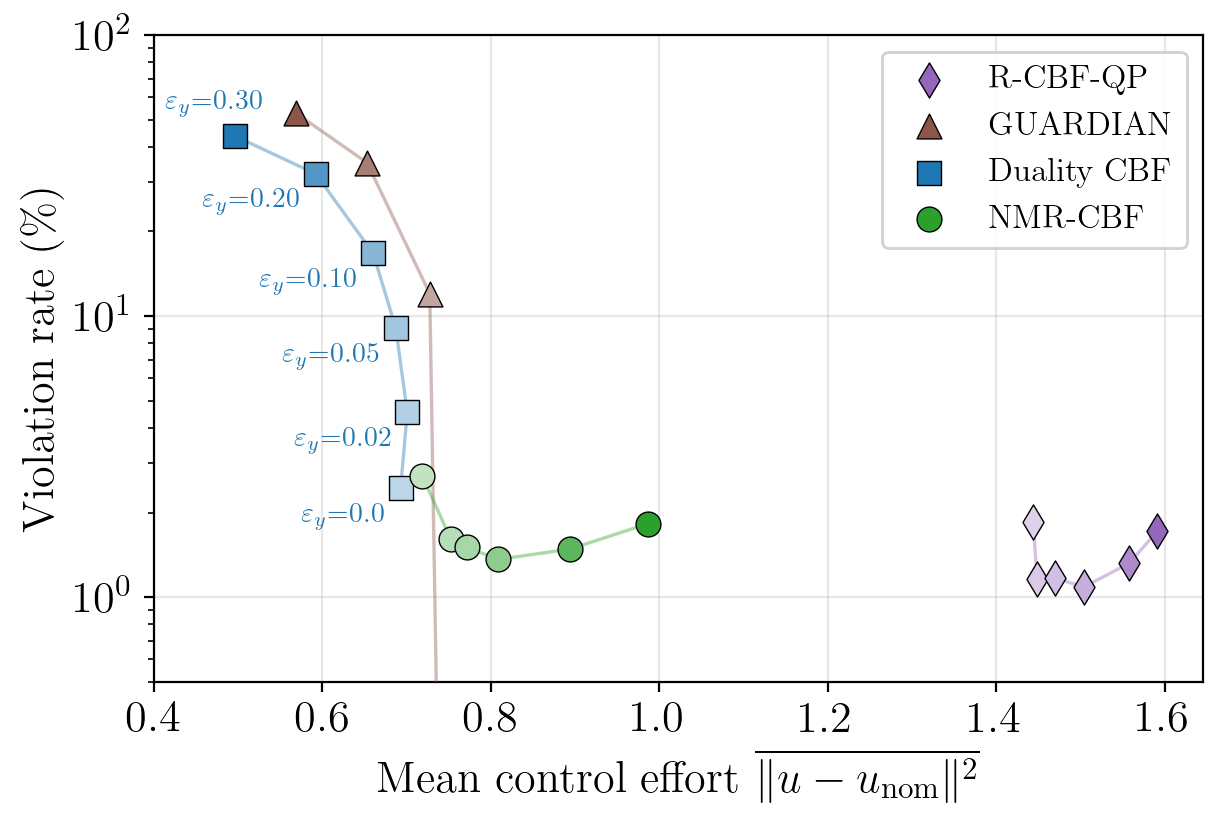

In [200]:
# ── LaTeX table + safety--performance trade-off across epsilon values ─────────
import math
import pickle
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.cm as cm

result_files = sorted(_mc_results_dir.glob('mc_eps_y_*.pkl'))

if not result_files:
    print("No saved MC results found. Run the save cell for each eps_y value first.")
else:
    all_results_full = []
    for f in result_files:
        with open(f, 'rb') as fh:
            all_results_full.append(pickle.load(fh))
    all_results_full.sort(key=lambda r: r['STATE_EPS_DUAL'][1])

    def _eps_filter(results, subset):
        if subset is None:
            return results
        return [r for r in results
                if any(abs(r['STATE_EPS_DUAL'][1] - e) < 1e-4
                       for e in subset)]

    # ── Subset selectors (both filter independently from the full loaded set) ─
    PLOT_EPS_SUBSET  = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3]  # None = all
    TABLE_EPS_SUBSET = [0.0, 0.05, 0.1, 0.3]                    # None = all

    plot_results  = _eps_filter(all_results_full, PLOT_EPS_SUBSET)
    table_results = _eps_filter(all_results_full, TABLE_EPS_SUBSET)

    approaches = list(all_results_full[0]['violation_rates'].keys())
    eps_vals   = [r['STATE_EPS_DUAL'][1] for r in plot_results]

    # ── LaTeX table ───────────────────────────────────────────────────────────
    # Display names (key = internal name, value = LaTeX label in table)
    TABLE_DISPLAY_NAMES = {
        'Nom+noise':   'Nominal',
        'CBF+noise':   'CBF',
        'CBF':         'CBF',
        'Duality CBF': 'Duality CBF',
        'GUARDIAN':    'GUARDIAN',
        'R-CBF-QP':    'R-CBF-QP',
        'R-CBF (0.2)': 'R-CBF (0.2)',
        'R-CBF (1.0)': 'R-CBF (1.0)',
        'MR-CBF':      'MR-CBF',
        'NMR-CBF':     'NMR-CBF',
    }
    # Category structure; any approach not listed here lands in Point-based robust
    # before NMR-CBF (which is always last in that category).
    TABLE_CATEGORIES = [
        ('Non-robust',                    ['Nom+noise', 'CBF+noise', 'CBF']),
        (r'\shortstack[l]{Set-based \\robust}',   ['Duality CBF', 'GUARDIAN']),
        (r'\shortstack[l]{Point-based \\robust}', None),  # None = auto-fill
    ]
    _explicit = {a for _, lst in TABLE_CATEGORIES if lst for a in lst}
    _extra = [a for a in approaches if a not in _explicit and a not in {'NMR-CBF', 'R-CBF-QP'}]
    TABLE_CATEGORIES[-1] = (
        TABLE_CATEGORIES[-1][0],
        ['R-CBF-QP'] + _extra + ['NMR-CBF']
    )

    table_eps_vals = [r['STATE_EPS_DUAL'][1] for r in table_results]
    n_eps    = len(table_eps_vals)
    col_spec = 'll' + 'c' * n_eps
    lines = [
        r'\begin{table}[t]', r'\centering',
        r'\caption{Violation rate (\%) vs.\ measurement uncertainty $\varepsilon_y$ (m)}',
        r'\label{tab:mc_violation_rates}',
        f'\\begin{{tabular}}{{{col_spec}}}', r'\toprule',
    ]
    header = 'Category & Approach'
    for eps in table_eps_vals:
        header += f' & $\\varepsilon_y = {eps:.2f}$'
    lines.append(header + r' \\')
    first_cat = True
    for cat_name, cat_approaches in TABLE_CATEGORIES:
        # Filter to approaches that actually appear in the data
        cat_rows = [a for a in cat_approaches if a in approaches]
        if not cat_rows:
            continue
        lines.append(r'\midrule')
        first_cat = False
        for i, approach in enumerate(cat_rows):
            disp = TABLE_DISPLAY_NAMES.get(approach, approach)
            if i == 0:
                row = f'\\multirow{{{len(cat_rows)}}}{{*}}{{{cat_name}}} & {disp}'
            else:
                row = f' & {disp}'
            for res in table_results:
                rate = res['violation_rates'].get(approach, float('nan'))
                row += f' & {100*rate:.1f}'
            lines.append(row + r' \\')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    print('\n'.join(lines))
    print(f'\n({len(table_results)} epsilon values, {len(approaches)} approaches)\n')
    # ── Safety--performance scatter across epsilon values ─────────────────────
    # Each method has a fixed base colour; saturation encodes eps_y.
    pol_base_colors = {
        'Nom+noise':    'C3',
        'CBF':          'C1',
        'R-CBF-QP':     'C4',
        'Duality CBF':  'C0',
        'R-CBF (0.2)':  'C6',
        'R-CBF (1.0)':  'C7',
        # 'MR-CBF':       'C8',
        'GUARDIAN':     'C5',
        'NMR-CBF':      'C2',
    }
    pol_markers_plot = {
        'Duality CBF': 's',    # square
        'GUARDIAN':    '^',    # triangle up
        'NMR-CBF':     'o',    # diamond
        'R-CBF-QP':    'd',    # plus (filled)
    }

    # ── Policy subset: set to None to plot all, or list names to include ──────
    PLOT_POLICIES = ['R-CBF-QP', 'GUARDIAN', 'Duality CBF', 'NMR-CBF']

    plot_approaches = (
        [a for a in PLOT_POLICIES if a in approaches]
        if PLOT_POLICIES is not None else approaches
    )
    plot_approaches = [a for a in plot_approaches if a != 'Nom+noise']

    eps_min = min(eps_vals)
    eps_max = max(eps_vals)

    def _desaturate(hex_color, saturation):
        r, g, b = mcolors.to_rgb(hex_color)
        r2 = 1.0 + saturation * (r - 1.0)
        g2 = 1.0 + saturation * (g - 1.0)
        b2 = 1.0 + saturation * (b - 1.0)
        return (r2, g2, b2)

    fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

    # Collect per-policy points ordered by eps_y, then draw lines + scatter
    for approach in plot_approaches:
        base = pol_base_colors.get(approach, 'k')
        base_rgb = mcolors.to_rgb(base)
        marker = pol_markers_plot.get(approach, 'o')
        xs_line, ys_line, cols_line, eps_line = [], [], [], []

        for res in plot_results:
            eps_y = res['STATE_EPS_DUAL'][1]
            if approach not in res['violation_rates']:
                continue
            viol   = 100 * res['violation_rates'][approach]
            effort = res['mean_effort'].get(approach, float('nan'))
            if math.isnan(effort):
                print(f'  WARNING: missing effort for {approach!r} at eps_y={eps_y:.4f} — skipping point')
                continue
            sat = (eps_y - eps_min) / (eps_max - eps_min + 1e-9)
            sat = 0.3 + 0.7 * sat
            col = _desaturate(base, sat)
            xs_line.append(effort)
            ys_line.append(viol)
            cols_line.append(col)
            eps_line.append(eps_y)

        if not xs_line:
            continue

        # Line connecting points in eps order (using base colour, semi-transparent)
        ax.plot(xs_line, ys_line, color=base_rgb, linewidth=1.2, alpha=0.4, zorder=3)

        # Scatter dots on top with saturation-encoded colour
        for x, y, c in zip(xs_line, ys_line, cols_line):
            ax.scatter(x, y, s=80, marker=marker, c=[c], edgecolors='k', linewidths=0.5, zorder=5)

        # Legend proxy: full-saturation dot
        ax.scatter([], [], c=[base_rgb], marker=marker, s=80, edgecolors='k',
                   linewidths=0.5, label=approach)

        if approach == 'Duality CBF':
            txt_kw = dict(fontsize=10, color=base_rgb, zorder=6,
                          bbox=dict(boxstyle='round,pad=0.1', alpha=0.0, ec='none'))
            for x, y, e in zip(xs_line, ys_line, eps_line):
                if y > 0:
                    # if e == 0.0:
                    #     side = 'center'
                    #     offset = (16, 20)
                    # elif np.isclose(e, 0.01):
                    #     side = 'center'
                    #     offset = (32, 8)
                    # elif np.isclose(e, 0.05):
                    #     side = 'center'
                    #     offset = (-12, -16)
                    # else:
                    #     side = 'center'
                    #     offset = (6, -15)
                    if np.isclose(e, 0.3):
                        side = 'center'
                        offset = (-8, 10)
                    else:
                        side = 'right'
                        offset = (-6, -12)
                    if e == 0.0:
                        label = f'$\\varepsilon_y$={e:.1f}'
                    else:
                        label = f'$\\varepsilon_y$={e:.2f}'
                    arrow_kw = (dict(arrowstyle="->", color=base_rgb, lw=0.8)
                                if (e == 0.0 or np.isclose(e, 0.01)) else None)
                    ax.annotate(label, xy=(x, y),
                                xytext=offset, textcoords="offset points",
                                ha=side, **txt_kw)
    ax.set_yscale('log')

    ax.set(
        xlabel=r'Mean control effort  $\overline{\|u - u_{\mathrm{nom}}\|^2}$',
        ylabel=r'Violation rate (\%)',
        yticks=[1, 10, 100],
        ylim=(0.5, 100),
        xlim=(0.4, None)
    )
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)

    ax.grid(alpha=0.3)
    plt.show()

\begin{table}[t]
\centering
\caption{Violation rate (\%) vs.\ measurement uncertainty $\varepsilon_y$ (m)}
\label{tab:mc_violation_rates}
\begin{tabular}{llccc}
\toprule
Category & Approach & $\varepsilon_y = 0.00$ & $\varepsilon_y = 0.10$ & $\varepsilon_y = 0.30$ \\
\midrule
\multirow{2}{*}{Non-robust} & Nominal & 100.0 & 100.0 & 99.9 \\
 & CBF & 3.8 & 3.3 & 12.0 \\
\midrule
\multirow{2}{*}{\shortstack[l]{Set-based \\robust}} & Duality CBF & 2.4 & 16.7 & 43.6 \\
 & GUARDIAN & 0.0 & 12.0 & 52.8 \\
\midrule
\multirow{4}{*}{\shortstack[l]{Point-based \\robust}} & R-CBF-QP & 1.9 & 1.1 & 1.7 \\
 & R-CBF (0.2) & 3.1 & 2.5 & 7.8 \\
 & R-CBF (1.0) & 1.7 & 1.1 & 2.0 \\
 & NMR-CBF & 2.7 & 1.4 & 1.8 \\
\bottomrule
\end{tabular}
\end{table}

(3 epsilon values, 8 approaches)



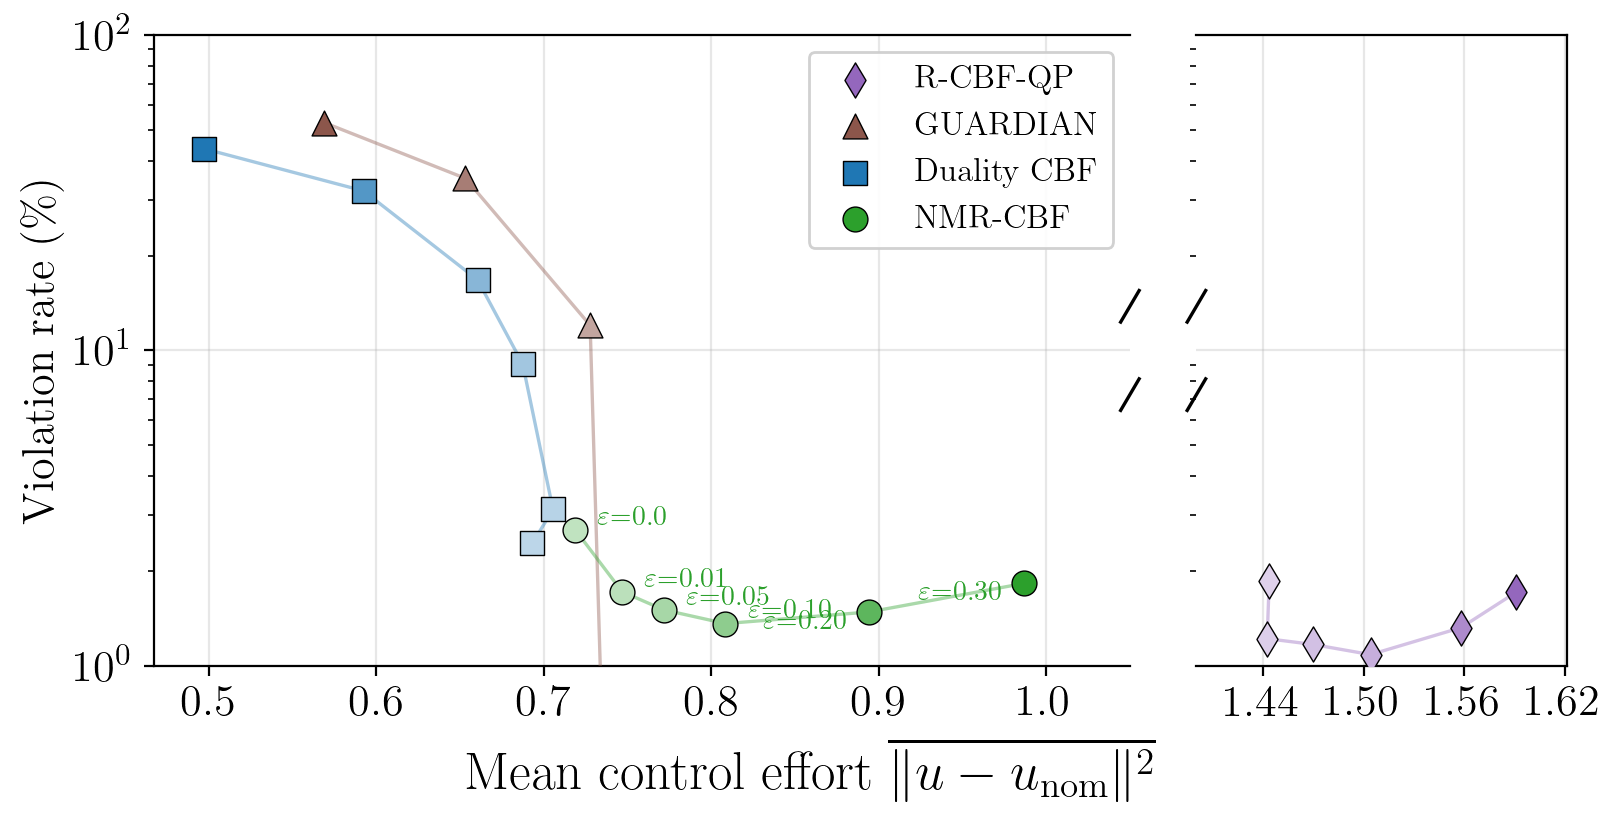

In [ ]:
# ── LaTeX table + safety--performance trade-off across epsilon values ─────────
import math
import pickle
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.cm as cm

result_files = sorted(_mc_results_dir.glob('mc_eps_y_*.pkl'))

if not result_files:
    print("No saved MC results found. Run the save cell for each eps_y value first.")
else:
    all_results_full = []
    for f in result_files:
        with open(f, 'rb') as fh:
            all_results_full.append(pickle.load(fh))
    all_results_full.sort(key=lambda r: r['STATE_EPS_DUAL'][1])

    def _eps_filter(results, subset):
        if subset is None:
            return results
        return [r for r in results
                if any(abs(r['STATE_EPS_DUAL'][1] - e) < 1e-4
                       for e in subset)]

    # ── Subset selectors (both filter independently from the full loaded set) ─
    PLOT_EPS_SUBSET  = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]  # None = all
    TABLE_EPS_SUBSET = [0.0, 0.1, 0.3]                    # None = all

    plot_results  = _eps_filter(all_results_full, PLOT_EPS_SUBSET)
    table_results = _eps_filter(all_results_full, TABLE_EPS_SUBSET)

    approaches = list(all_results_full[0]['violation_rates'].keys())
    eps_vals   = [r['STATE_EPS_DUAL'][1] for r in plot_results]

    # ── LaTeX table ───────────────────────────────────────────────────────────
    # Display names (key = internal name, value = LaTeX label in table)
    TABLE_DISPLAY_NAMES = {
        'Nom+noise':   'Nominal',
        'CBF+noise':   'CBF',
        'CBF':         'CBF',
        'Duality CBF': 'Duality CBF',
        'GUARDIAN':    'GUARDIAN',
        'R-CBF-QP':    'R-CBF-QP',
        'R-CBF (0.2)': 'R-CBF (0.2)',
        'R-CBF (1.0)': 'R-CBF (1.0)',
        'MR-CBF':      'MR-CBF',
        'NMR-CBF':     'NMR-CBF',
    }
    # Category structure; any approach not listed here lands in Point-based robust
    # before NMR-CBF (which is always last in that category).
    TABLE_CATEGORIES = [
        ('Non-robust',                    ['Nom+noise', 'CBF+noise', 'CBF']),
        (r'\shortstack[l]{Set-based \\robust}',   ['Duality CBF', 'GUARDIAN']),
        (r'\shortstack[l]{Point-based \\robust}', None),  # None = auto-fill
    ]
    _explicit = {a for _, lst in TABLE_CATEGORIES if lst for a in lst}
    _extra = [a for a in approaches if a not in _explicit and a not in {'NMR-CBF', 'R-CBF-QP'}]
    TABLE_CATEGORIES[-1] = (
        TABLE_CATEGORIES[-1][0],
        ['R-CBF-QP'] + _extra + ['NMR-CBF']
    )

    table_eps_vals = [r['STATE_EPS_DUAL'][1] for r in table_results]
    n_eps    = len(table_eps_vals)
    col_spec = 'll' + 'c' * n_eps
    lines = [
        r'\begin{table}[t]', r'\centering',
        r'\caption{Violation rate (\%) vs.\ measurement uncertainty $\varepsilon_y$ (m)}',
        r'\label{tab:mc_violation_rates}',
        f'\\begin{{tabular}}{{{col_spec}}}', r'\toprule',
    ]
    header = 'Category & Approach'
    for eps in table_eps_vals:
        header += f' & $\\varepsilon_y = {eps:.2f}$'
    lines.append(header + r' \\')
    first_cat = True
    for cat_name, cat_approaches in TABLE_CATEGORIES:
        # Filter to approaches that actually appear in the data
        cat_rows = [a for a in cat_approaches if a in approaches]
        if not cat_rows:
            continue
        lines.append(r'\midrule')
        first_cat = False
        for i, approach in enumerate(cat_rows):
            disp = TABLE_DISPLAY_NAMES.get(approach, approach)
            if i == 0:
                row = f'\\multirow{{{len(cat_rows)}}}{{*}}{{{cat_name}}} & {disp}'
            else:
                row = f' & {disp}'
            for res in table_results:
                rate = res['violation_rates'].get(approach, float('nan'))
                row += f' & {100*rate:.1f}'
            lines.append(row + r' \\')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    print('\n'.join(lines))
    print(f'\n({len(table_results)} epsilon values, {len(approaches)} approaches)\n')
    # ── Safety--performance scatter across epsilon values ─────────────────────
    # Each method has a fixed base colour; saturation encodes eps_y.
    pol_base_colors = {
        'Nom+noise':    'C3',
        'CBF':          'C1',
        'R-CBF-QP':     'C4',
        'Duality CBF':  'C0',
        'R-CBF (0.2)':  'C6',
        'R-CBF (1.0)':  'C7',
        # 'MR-CBF':       'C8',
        'GUARDIAN':     'C5',
        'NMR-CBF':      'C2',
    }
    pol_markers_plot = {
        'Duality CBF': 's',    # square
        'GUARDIAN':    '^',    # triangle up
        'NMR-CBF':     'o',    # circle
        'R-CBF-QP':    'd',    # thin diamond
    }

    PLOT_POLICIES = ['R-CBF-QP', 'GUARDIAN', 'Duality CBF', 'NMR-CBF']

    plot_approaches = (
        [a for a in PLOT_POLICIES if a in approaches]
        if PLOT_POLICIES is not None else approaches
    )
    plot_approaches = [a for a in plot_approaches if a != 'Nom+noise']

    eps_min = min(eps_vals)
    eps_max = max(eps_vals)

    def _desaturate(hex_color, saturation):
        r, g, b = mcolors.to_rgb(hex_color)
        return (1.0 + saturation*(r-1.0), 1.0 + saturation*(g-1.0), 1.0 + saturation*(b-1.0))

    # Collect per-approach (effort, viol, eps, col, base_rgb, marker) tuples
    _pts = {}
    for approach in plot_approaches:
        base     = pol_base_colors.get(approach, "k")
        base_rgb = mcolors.to_rgb(base)
        marker   = pol_markers_plot.get(approach, "o")
        pts = []
        for res in plot_results:
            eps_y = res['STATE_EPS_DUAL'][1]
            if approach not in res['violation_rates']:
                continue
            viol   = 100 * res['violation_rates'][approach]
            effort = res['mean_effort'].get(approach, float('nan'))
            if math.isnan(effort):
                print(f'  WARNING: missing effort for {approach!r} at eps_y={eps_y:.4f}')
                continue
            sat = 0.3 + 0.7 * (eps_y - eps_min) / (eps_max - eps_min + 1e-9)
            col = _desaturate(base, sat)
            pts.append((effort, viol, eps_y, col, base_rgb, marker))
        _pts[approach] = pts

    _all_efforts = [e for pts in _pts.values() for e, *_ in pts]

    # ── Split-axis setup ───────────────────────────────────────────────────────────
    x_gap_lo, x_gap_hi = 1.1, 1.3
    left_efforts  = [e for e in _all_efforts if e <= x_gap_lo]
    right_efforts = [e for e in _all_efforts if e >= x_gap_hi]
    has_split = len(right_efforts) > 0

    if has_split:
        x_left_lo  = min(left_efforts)  - 0.03
        x_left_hi  = x_gap_lo           - 0.05
        x_right_lo = x_gap_hi           + 0.1
        x_right_hi = max(right_efforts) + 0.03

        left_span  = x_left_hi  - x_left_lo
        right_span = x_right_hi - x_right_lo
        wr = [left_span, right_span]

        fig, (ax_l, ax_r) = plt.subplots(
            1, 2, sharey=True, figsize=(8, 4), layout='constrained',
            gridspec_kw={'width_ratios': wr, 'wspace': 0.06}
        )
        ax_l.set_xlim(x_left_lo,  x_left_hi)
        ax_r.set_xlim(x_right_lo, x_right_hi)
        ax_r.xaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))

        ax_l.spines['right'].set_visible(False)
        ax_r.spines['left'].set_visible(False)
        ax_r.tick_params(left=False)

        def _dest(effort):
            return ax_l if effort <= x_gap_lo else ax_r
        main_ax   = ax_l
        both_axes = [ax_l, ax_r]

    else:
        fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
        ax.set_xlim(left=min(_all_efforts) - 0.03 if _all_efforts else 0.0)

        def _dest(effort):
            return ax
        main_ax   = ax
        both_axes = [ax]
        ax_l = ax_r = ax

    # ── Plot each approach ──────────────────────────────────────────────────────────
    for approach, pts in _pts.items():
        if not pts:
            continue
        base_rgb = pts[0][4]
        marker   = pts[0][5]

        # Connecting lines drawn per-panel to stay within each axis
        for ax_plot in both_axes:
            seg = [(p[0], p[1]) for p in pts if _dest(p[0]) is ax_plot]
            if len(seg) > 1:
                ax_plot.plot([s[0] for s in seg], [s[1] for s in seg],
                             color=base_rgb, linewidth=1.2, alpha=0.4, zorder=3)

        for x, y, eps_y, col, _, _ in pts:
            _dest(x).scatter(x, y, s=80, marker=marker, c=[col],
                             edgecolors="k", linewidths=0.5, zorder=5)

        main_ax.scatter([], [], c=[base_rgb], marker=marker, s=80,
                        edgecolors="k", linewidths=0.5, label=approach)

        if approach == 'NMR-CBF':
            txt_kw = dict(fontsize=10, color=base_rgb, zorder=6,
                          bbox=dict(boxstyle='round,pad=0.1', alpha=0.0, ec='none'))
            for x, y, e, *_ in pts:
                if y > 0:
                    side   = 'left'  if e < 0.15 else 'right'
                    offset = (8, 2)  if e < 0.15 else (-8, -6)
                    lbl    = f'$\\varepsilon$={e:.1f}' if e == 0.0 else f'$\\varepsilon$={e:.2f}'
                    _dest(x).annotate(lbl, xy=(x, y),
                                      xytext=offset, textcoords="offset points",
                                      ha=side, **txt_kw)

    # ── Break marks: parallel diagonal slashes ────────────────────────────
    if has_split:
        # For parallel marks in pixel space: d_x * panel_width_px = const.
        # Panel widths are proportional to wr, so scale d_x inversely.
        d_y  = 0.025
        d_xl = d_y * (wr[1] / wr[0])   # left panel (wider data range -> smaller d_x)
        d_xr = d_y                       # right panel reference
        kw = dict(color="k", clip_on=False, linewidth=1.2)
        for y0 in (0.43, 0.57):
            ax_l.plot([1-d_xl, 1+d_xl], [y0-d_y, y0+d_y],
                      transform=ax_l.transAxes, **kw)
            ax_r.plot([-d_xr, +d_xr], [y0-d_y, y0+d_y],
                      transform=ax_r.transAxes, **kw)

    # ── Labels, scale, legend ──────────────────────────────────────────────────────────
    for ax_plot in both_axes:
        ax_plot.set_yscale("log")
        ax_plot.set(yticks=[1, 10, 100], ylim=(1.0, 100))
        ax_plot.grid(alpha=0.3)

    ax_l.set_ylabel(r'Violation rate (\%)')
    fig.supxlabel(r'Mean control effort  $\overline{\|u - u_{\mathrm{nom}}\|^2}$')
    main_ax.legend(fontsize=12, loc='upper right', framealpha=0.9)

    plt.show()


## Timing

Per-step compute time for each policy.

  Nom+noise       0.6 ms +/- 0.3 ms  (0.011 ms/step)
  CBF+noise       22.6 ms +/- 0.3 ms  (0.452 ms/step)
  R-CBF-QP        26.0 ms +/- 0.2 ms  (0.520 ms/step)
  Duality CBF     153.9 ms +/- 0.2 ms  (3.078 ms/step)
  R-CBF (0.2)     22.4 ms +/- 0.2 ms  (0.448 ms/step)
  R-CBF (1.0)     26.8 ms +/- 0.3 ms  (0.537 ms/step)
  NMR-CBF         23.5 ms +/- 0.2 ms  (0.470 ms/step)
  GUARDIAN        3.6 ms +/- 0.1 ms  (0.072 ms/step)


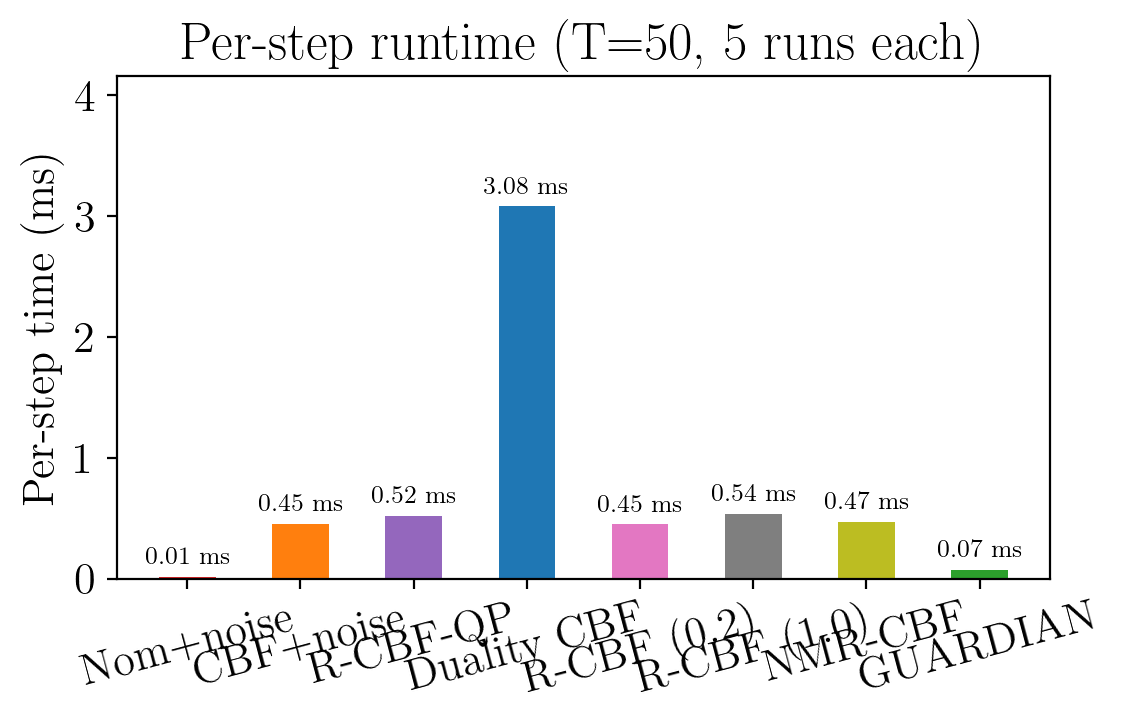

In [ ]:
import time

x_time    = jnp.array(list(x_ics.values())[0])
bias_time = _sample_bias(BASE_KEY)

# Pre-compile all policies
for fn in [rollout_nom_noisy, rollout_cbf_noisy, rollout_rcbf, rollout_duality,
           rollout_rcbf_02, rollout_rcbf_10,
           rollout_nmr_cbf, rollout_guardian]:
    fn(x_time, bias_time)

N_REPEATS = 5
timing = {}
for pol_name, rollout_fn in [('Nom+noise',   rollout_nom_noisy),
                              ('CBF+noise',   rollout_cbf_noisy),
                              ('R-CBF-QP',    rollout_rcbf),
                              ('Duality CBF', rollout_duality),
                              ('R-CBF (0.2)', rollout_rcbf_02),
                              ('R-CBF (1.0)', rollout_rcbf_10),
                              ('NMR-CBF',     rollout_nmr_cbf),
                              ('GUARDIAN',     rollout_guardian),
                              ]:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(rollout_fn(x_time, bias_time))
        times.append(time.perf_counter() - t0)
    timing[pol_name] = times
    print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms +/- {np.std(times)*1e3:.1f} ms'
          f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

# # MR-CBF timing (Python loop, not JIT)
# for pol_name, rollout_fn in [('MR-CBF',      _mrcbf_rollout),
#                             #   ('NMR+RCBF',    rollout_nmr_rcbf)
#                               ]:
#     times = []
#     for _ in range(N_REPEATS):
#         t0 = time.perf_counter()
#         jax.block_until_ready(rollout_fn(x_time, bias_time))
#         times.append(time.perf_counter() - t0)
#     timing[pol_name] = times
#     print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms ± {np.std(times)*1e3:.1f} ms'
#           f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

names    = list(timing.keys())
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
pol_cols = ['C3', 'C1', 'C4', 'C0', 'C6', 'C7', 'C8', 'C2', 'C5', 'C9']   # matches pol_styles

fig, ax = plt.subplots(figsize=(5.5, 3.5), layout='constrained')
bars = ax.bar(names, per_step, color=pol_cols[:len(names)], width=0.5)
ax.bar_label(bars, labels=[f'{v:.2f} ms' for v in per_step], padding=3, fontsize=9)
ax.set(ylabel='Per-step time (ms)', ylim=(0, max(per_step) * 1.35),
       title=f'Per-step runtime (T={T}, {N_REPEATS} runs each)')
ax.tick_params(axis='x', labelrotation=15)
plt.show()
